In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.spatial.transform import Rotation


def plot_ring_arcs_clean(
    values,
    eta_centers_deg,
    two_theta_centers_deg,
    two_theta_widths_deg,
    dist_mm,
    two_theta_max_deg,
    cmap="cividis",
    vmin=None,
    vmax=None,
    eps = 1,
    eps2 = 1,
):
    """
    Plot ring-arc data on a square Cartesian figure with no axes or colorbar.

    Parameters
    ----------
    values : array, shape (N_eta, N_2theta)
        Data values for each eta bin and each ring.
    eta_centers_deg : array, shape (N_eta,)
        Linearly spaced eta bin centers in degrees.
    two_theta_centers_deg : array, shape (N_2theta,)
        Ring center positions in 2theta degrees.
    two_theta_widths_deg : array, shape (N_2theta,)
        Ring thicknesses in 2theta degrees.
    dist_mm : float
        Sample-detector distance in mm.
    two_theta_max_deg : float
        Outer radial limit in 2theta for the plotted region.
    """

    def edges_from_linear_centers(c):
        c = np.asarray(c, dtype=float)
        if len(c) < 2:
            raise ValueError("eta_centers_deg must contain at least 2 points")
        step = c[1] - c[0]
        if not np.allclose(np.diff(c), step):
            raise ValueError("eta_centers_deg must be linearly spaced")
        e = np.empty(len(c) + 1, dtype=float)
        e[1:-1] = 0.5 * (c[:-1] + c[1:])
        e[0] = c[0] - 0.5 * step
        e[-1] = c[-1] + 0.5 * step
        return e

    def detector_radius(two_theta_deg):
        return dist_mm * np.tan(np.deg2rad(two_theta_deg))

    def build_intervals(centers, widths):
        centers = np.asarray(centers, dtype=float)
        widths = np.asarray(widths, dtype=float)

        lowers = centers - 0.5 * widths
        uppers = centers + 0.5 * widths

        order = np.argsort(centers)
        lowers = lowers[order]
        uppers = uppers[order]

        if np.any(lowers[1:] < uppers[:-1]):
            raise ValueError("Ring intervals overlap")

        intervals = []
        current = 0.0

        for i, (lo, hi) in enumerate(zip(lowers, uppers)):
            if lo > current:
                intervals.append((current, lo, None))
            intervals.append((lo, hi, order[i]))
            current = hi

        if current < two_theta_max_deg:
            intervals.append((current, two_theta_max_deg, None))

        return intervals

    values = np.asarray(values)
    eta_centers_deg = np.asarray(eta_centers_deg, dtype=float)
    two_theta_centers_deg = np.asarray(two_theta_centers_deg, dtype=float)
    two_theta_widths_deg = np.asarray(two_theta_widths_deg, dtype=float)

    n_eta = len(eta_centers_deg)
    n_rings = len(two_theta_centers_deg)

    if values.shape != (n_eta, n_rings):
        raise ValueError(
            f"values must have shape ({n_eta}, {n_rings}), got {values.shape}"
        )

    eta_edges = edges_from_linear_centers(eta_centers_deg)
    intervals = build_intervals(two_theta_centers_deg, two_theta_widths_deg)

    z_rows = []
    radial_edges = [intervals[0][0]]

    for lo, hi, idx in intervals:
        radial_edges.append(hi)
        if idx is None:
            z_rows.append(np.zeros(n_eta, dtype=values.dtype))
        else:
            # values is (N_eta, N_2theta), but pcolormesh wants (N_radial, N_eta)
            z_rows.append(values[:, idx])

    Z = np.asarray(z_rows)  # shape: (N_intervals, N_eta)
    radial_edges = np.asarray(radial_edges, dtype=float)

    r_edges = detector_radius(radial_edges)

    Eta, R = np.meshgrid(np.deg2rad(eta_edges), r_edges, indexing="xy")
    X = R * np.cos(Eta)
    Y = R * np.sin(Eta)

    fig, ax = plt.subplots(figsize=(20, 20))

    if vmin is None:
        vmin = float(np.min(Z))
    if vmax is None:
        vmax = float(np.max(Z))

    cmap_obj = plt.get_cmap(cmap)

    if vmax > vmin:
        zero_norm = (0.0 - vmin) / (vmax - vmin)
        zero_norm = np.clip(zero_norm, 0.0, 1.0)
    else:
        zero_norm = 0.0

    bg_color = cmap_obj(LogNorm(vmin=eps, vmax=vmax)(eps2))
    ax.set_facecolor(bg_color)
    fig.patch.set_facecolor(bg_color)

    pcm = ax.pcolormesh(
        X,
        Y,
        Z,
        shading="flat",
        cmap=cmap,
        norm=LogNorm(vmin=eps, vmax=vmax),
    )

    phi_deg = np.linspace(eta_edges[0], eta_edges[-1], 1000)
    phi = np.deg2rad(phi_deg)

    for c in two_theta_centers_deg:
        r = detector_radius(c)
        ax.plot(r * np.cos(phi), r * np.sin(phi), color="red", lw=1.0, alpha=0.35)


    rmax = r_edges.max()
    ax.set_xlim(-rmax, rmax)
    ax.set_ylim(-rmax, rmax)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

    return fig, ax, pcm

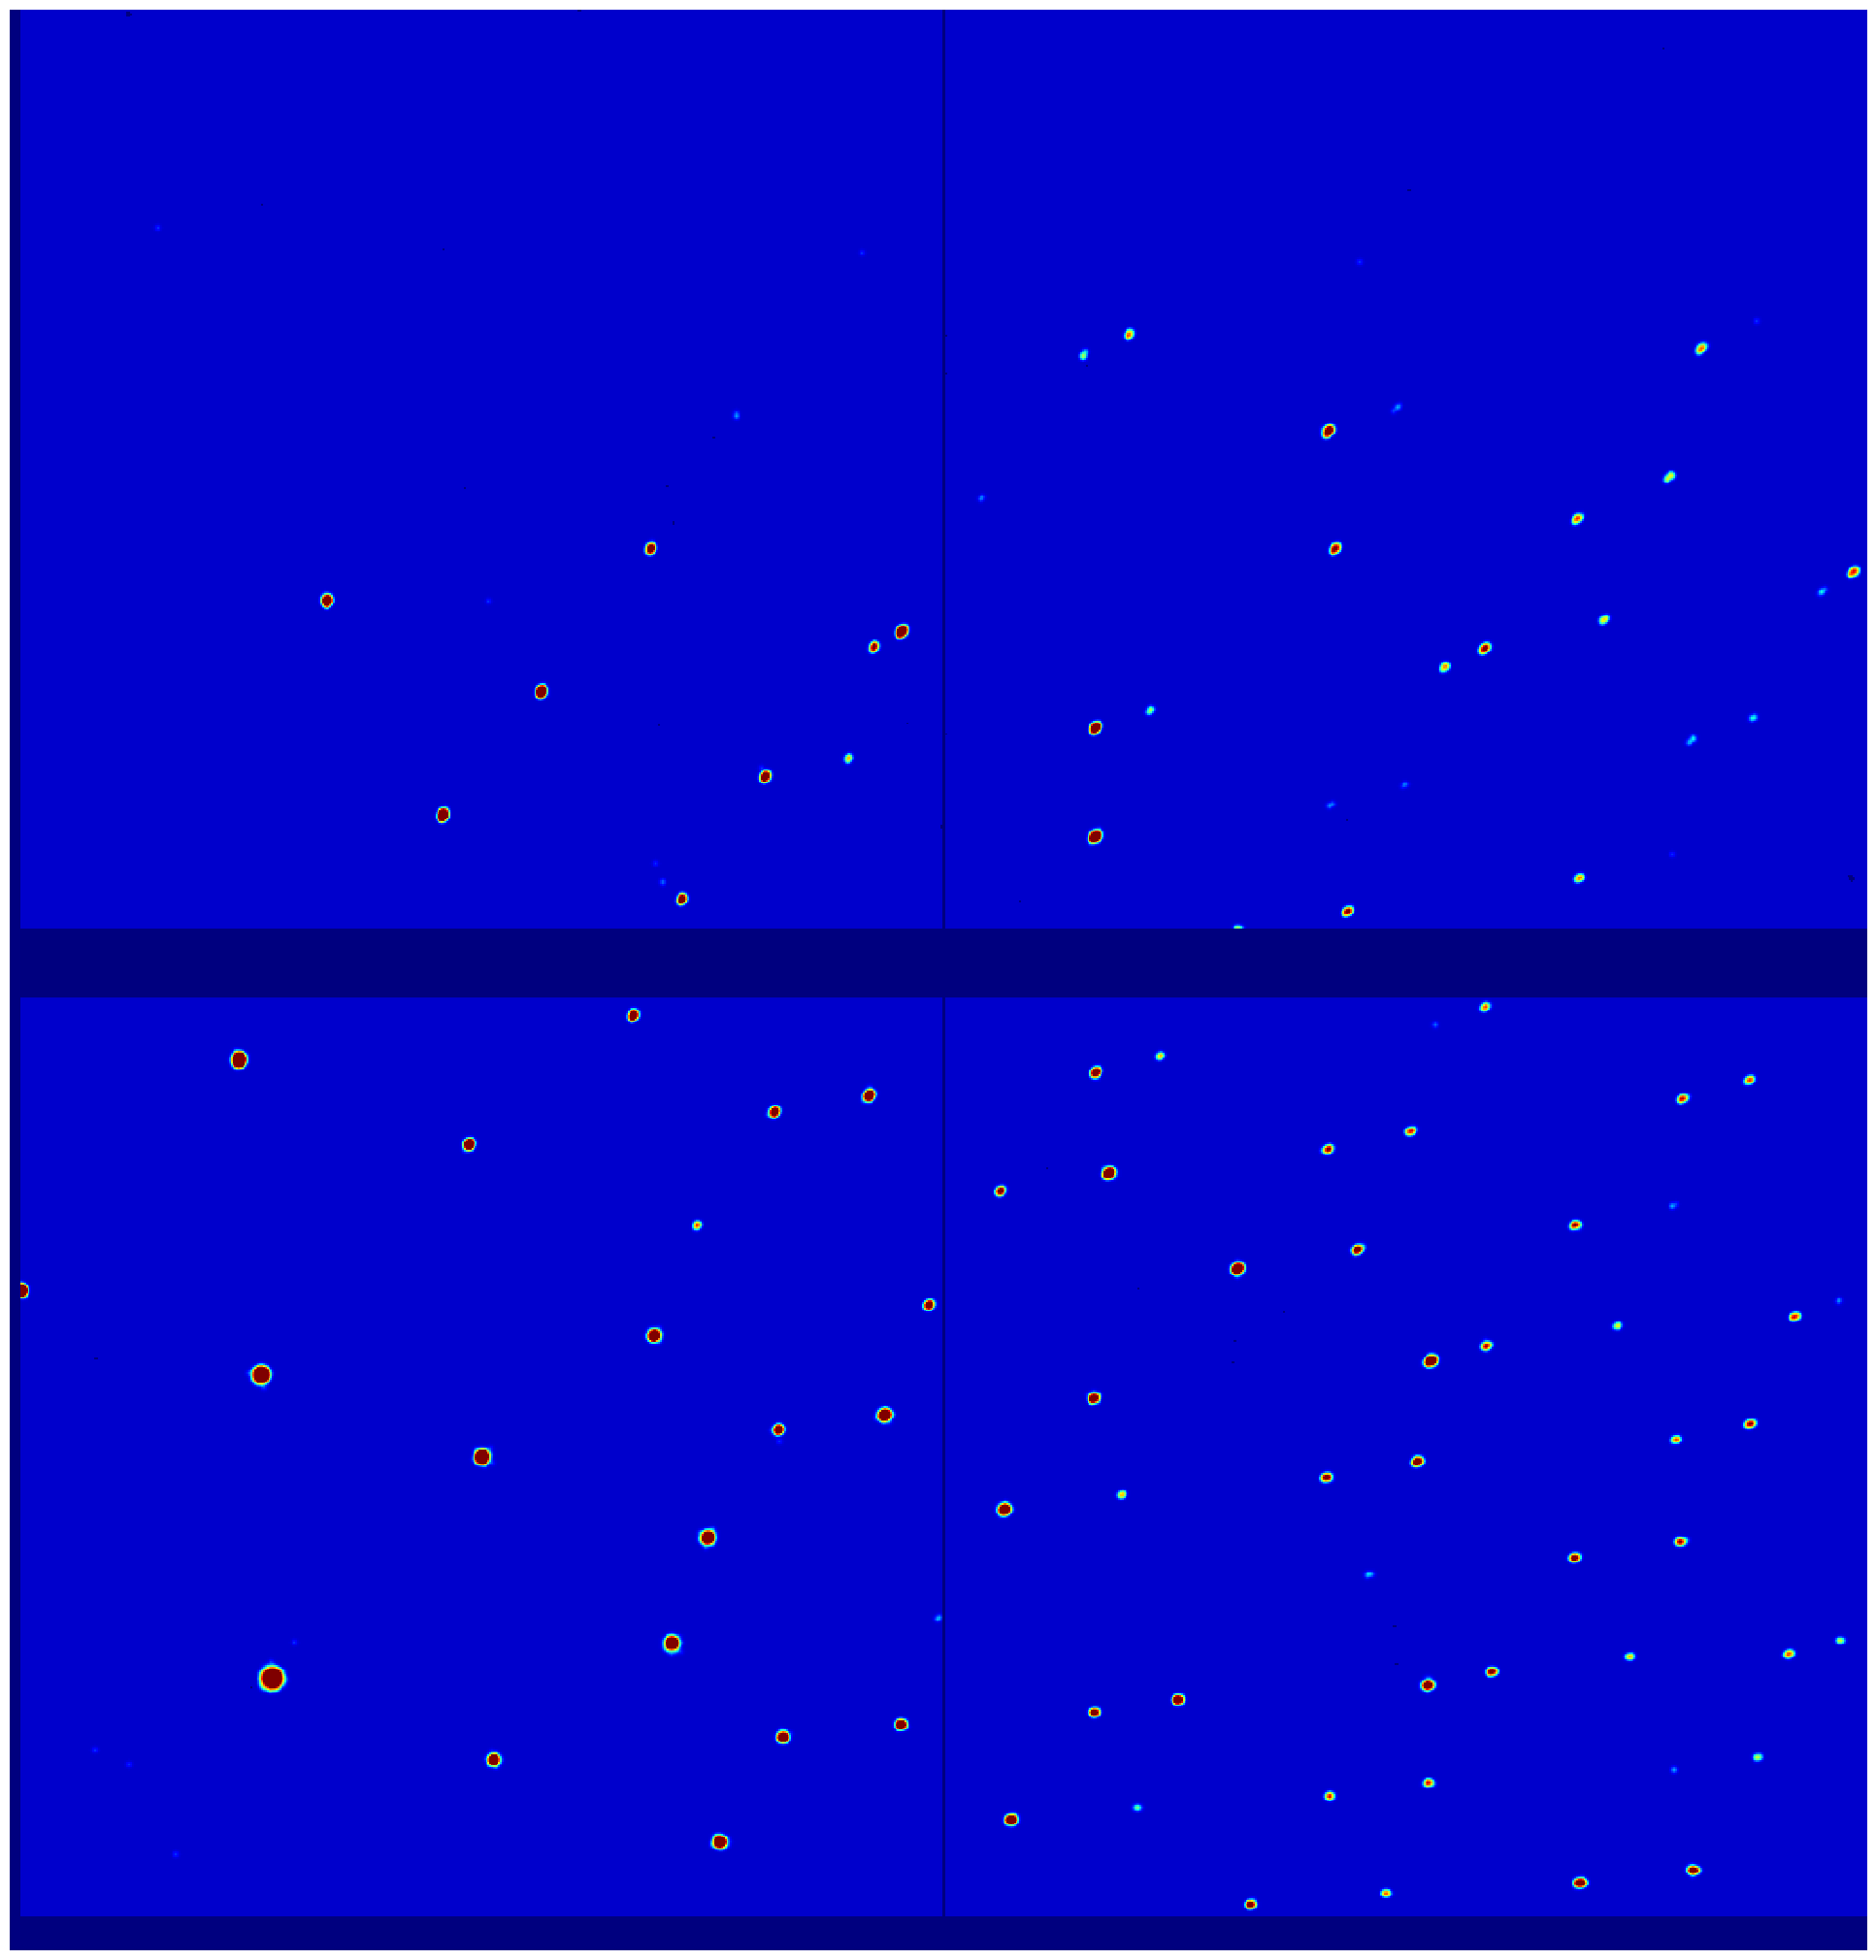

In [4]:
import os
import sys
import sys
from pathlib import Path


import h5py
import hdf5plugin
import numpy as np
from pathlib import Path
from diffractom import SinglePhaseForwardOperator
import yaml

import pyopencl.array as clarray
from diffractom import Grid
from diffractom import Material
import matplotlib.pyplot as plt

# ---------------------------
# CREATE RUN FOLDER
# ---------------------------

RECON_PATH  = Path('/work3/msaca/textomo_run_026/reconstruction.h5')
OUT_DIR = Path('/work3/msaca/textomo_run_026/detector_plots')
OUT_DIR.mkdir(parents=True, exist_ok=True)




path = '/work3/msaca/eiger_0000.h5'
with h5py.File(path, 'r') as f:
    nframes = f["entry_0000/measurement/data"].shape[0]
    frames = f["entry_0000/measurement/data"][0: 30 *nframes // 180] # 30 degrees

frames[frames <= 2 ] = 0 # remove noise less than 2 counts
integrated_frame = frames.sum(axis=0)

mask = integrated_frame == integrated_frame.max()
_s = integrated_frame.copy().astype(float)

from scipy.ndimage import gaussian_filter
_s[mask] = 0
_s = gaussian_filter(_s,1)


_s[mask] = -0.5
#_s[_s==0] = 0

#detector_image = gaussian_filter(detector_image, sigma=2.0)
fig, ax = plt.subplots(figsize=(20, 20))


# transparent background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

from matplotlib.colors import LogNorm
eps = 5
nx, ny = _s.shape
_s = _s[nx//2:,ny//2:]
ax.imshow(
    4*_s+eps,
    interpolation='nearest',
    cmap='jet',
    norm=LogNorm(vmin=eps-1, vmax=100),
    origin='lower',
)

# remove everything
ax.axis("off")

# remove all margins
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# save
fig.savefig(
    OUT_DIR / Path("detector_discrete.png"),
    dpi=200,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)


In [5]:
print("Saving results to:", OUT_DIR)

# ------------------    ---------
# CONFIG
# ---------------------------
config_path = "/zhome/71/c/146676/texture_tomography/" + "configs/" + "aluminum_config.yaml"

with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)

N_eta = cfg['N_eta']
N_Omega = cfg['N_Omega']
N_theta = cfg['N_theta']
Nx = cfg['Nx']
Ny = cfg['Ny']
My = cfg['My']
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']

filename = datapath + filename_integrated

Saving results to: /work3/msaca/textomo_run_026/detector_plots


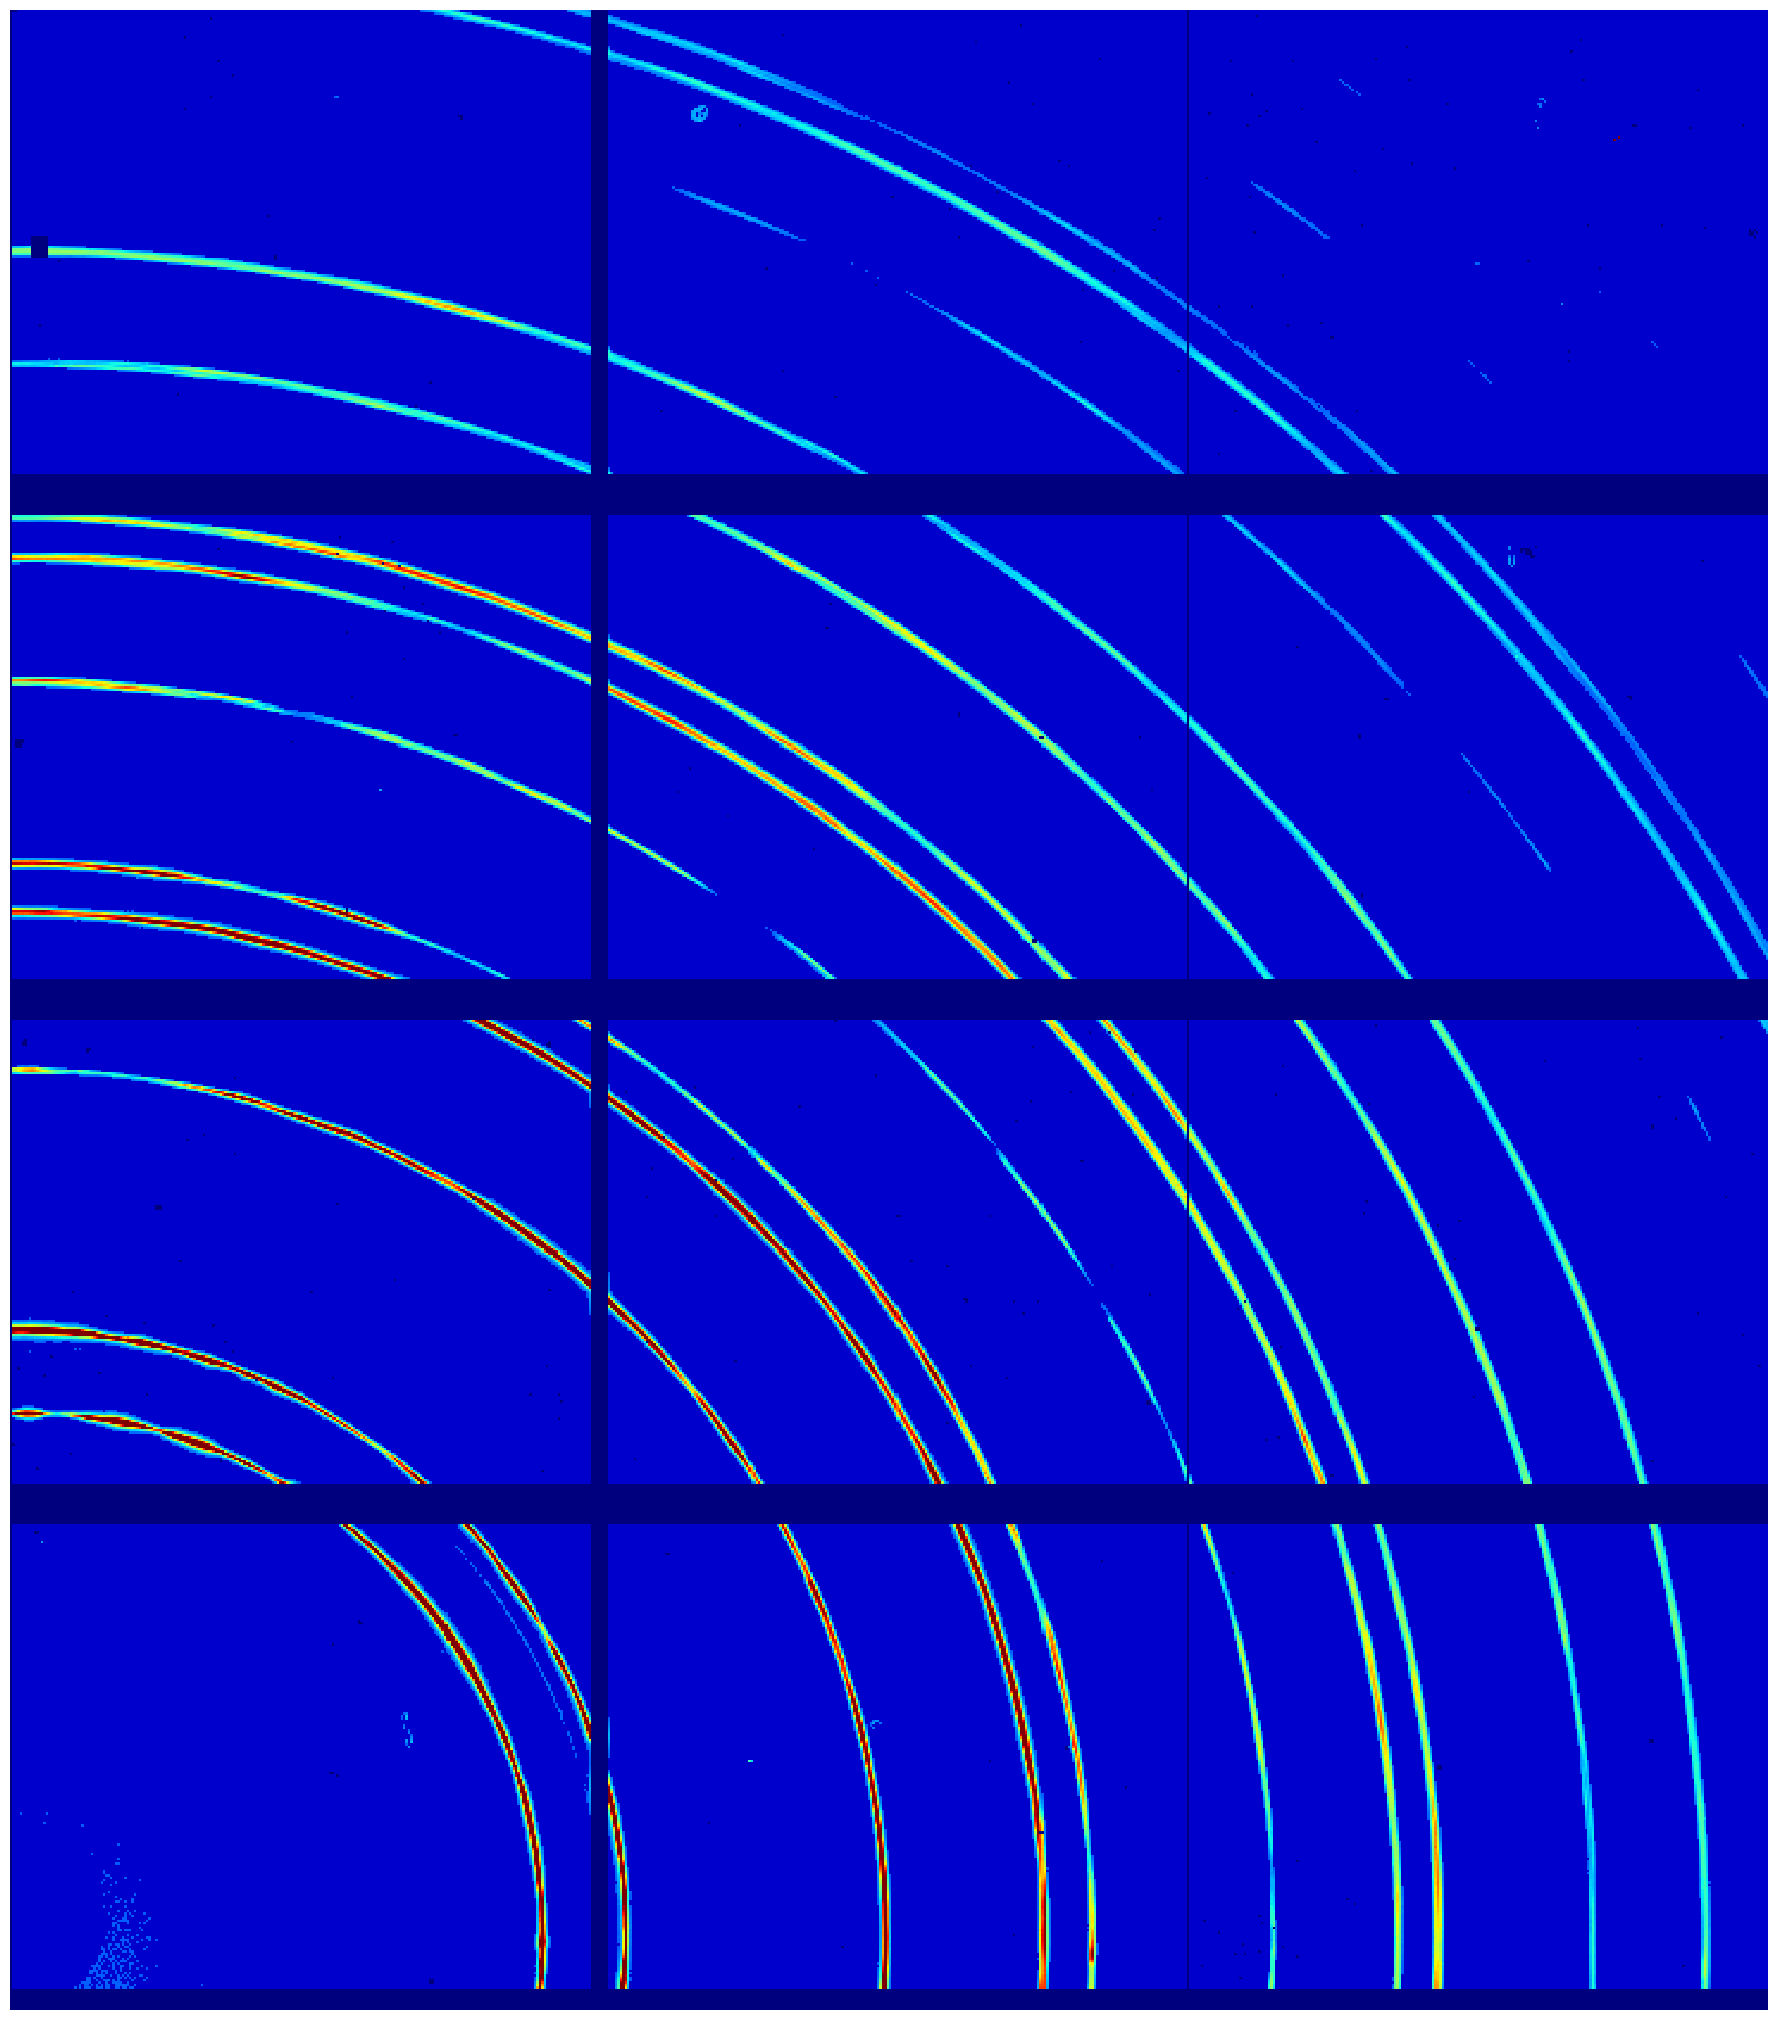

In [7]:
import h5py
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

with h5py.File(datapath + "scan-0054_pilatus.h5", 'r') as f:
    dataset = f['entry/instrument/pilatus/data']
    detector_image = dataset[3003*6:3003*6+9000].mean(axis=0)*6
    nx, ny = detector_image.shape
    detector_image = detector_image[nx//2:,ny//2:]


In [ ]:

#detector_image = gaussian_filter(detector_image, sigma=2.0)
fig, ax = plt.subplots(figsize=(20, 20))


# transparent background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
detector_image[detector_image<0] = -2
detector_image[(detector_image<=3)*(detector_image>=0)] = 0

from matplotlib.colors import LogNorm
eps = 5
ax.imshow(
    detector_image+eps,
    interpolation='nearest',
    cmap='jet',
    norm=LogNorm(vmin=4, vmax=100),
    origin='lower',
)

# remove everything
ax.axis("off")

# remove all margins
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# save
fig.savefig(
    OUT_DIR / Path("detector_continuous.png"),
    dpi=200,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

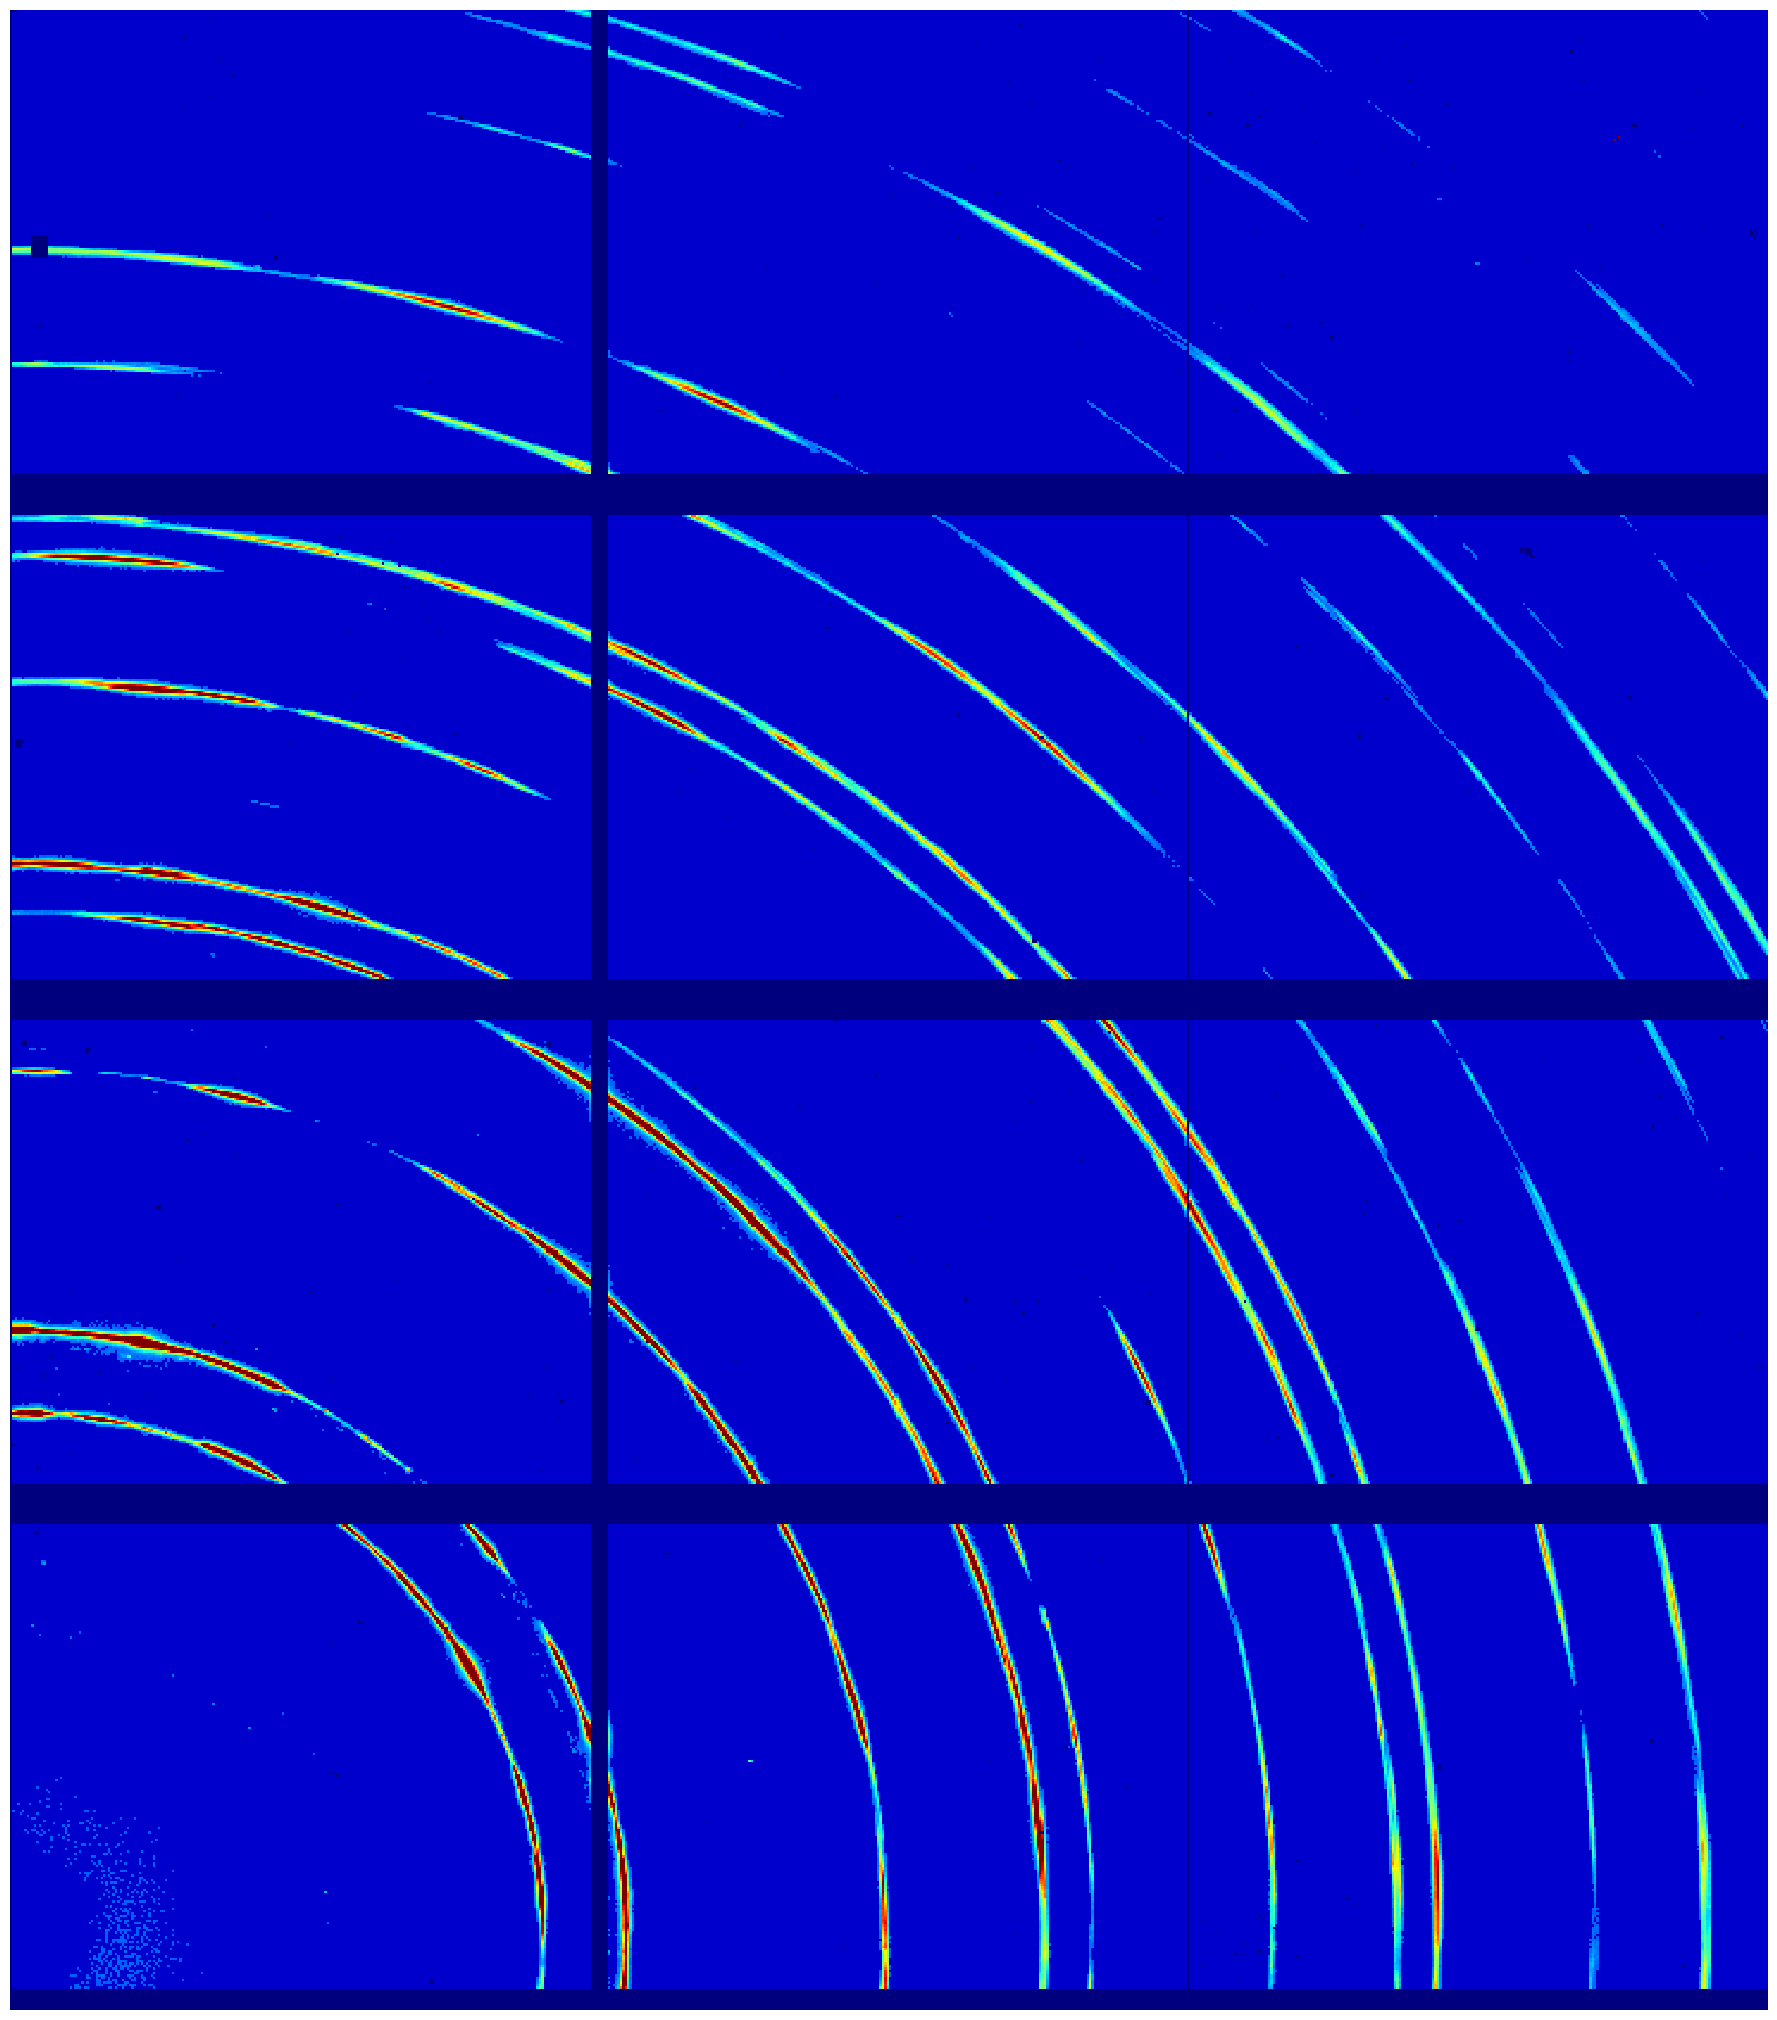

In [9]:
import h5py
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

with h5py.File(datapath + "scan-0054_pilatus.h5", 'r') as f:
    dataset = f['entry/instrument/pilatus/data']
    detector_image = dataset[3003*6:3003*6+400].mean(axis=0)*6
    nx, ny = detector_image.shape
    detector_image = detector_image[nx//2:,ny//2:]

#detector_image = gaussian_filter(detector_image, sigma=2.0)
fig, ax = plt.subplots(figsize=(20, 20))


# transparent background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
detector_image[detector_image<0] = -2
detector_image[(detector_image<=3)*(detector_image>=0)] = 0

from matplotlib.colors import LogNorm
eps = 5
ax.imshow(
    detector_image+eps,
    interpolation='nearest',
    cmap='jet',
    norm=LogNorm(vmin=4, vmax=100),
    origin='lower',
)

# remove everything
ax.axis("off")

# remove all margins
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# save
fig.savefig(
    OUT_DIR / Path("detector_almostcontinuous.png"),
    dpi=200,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

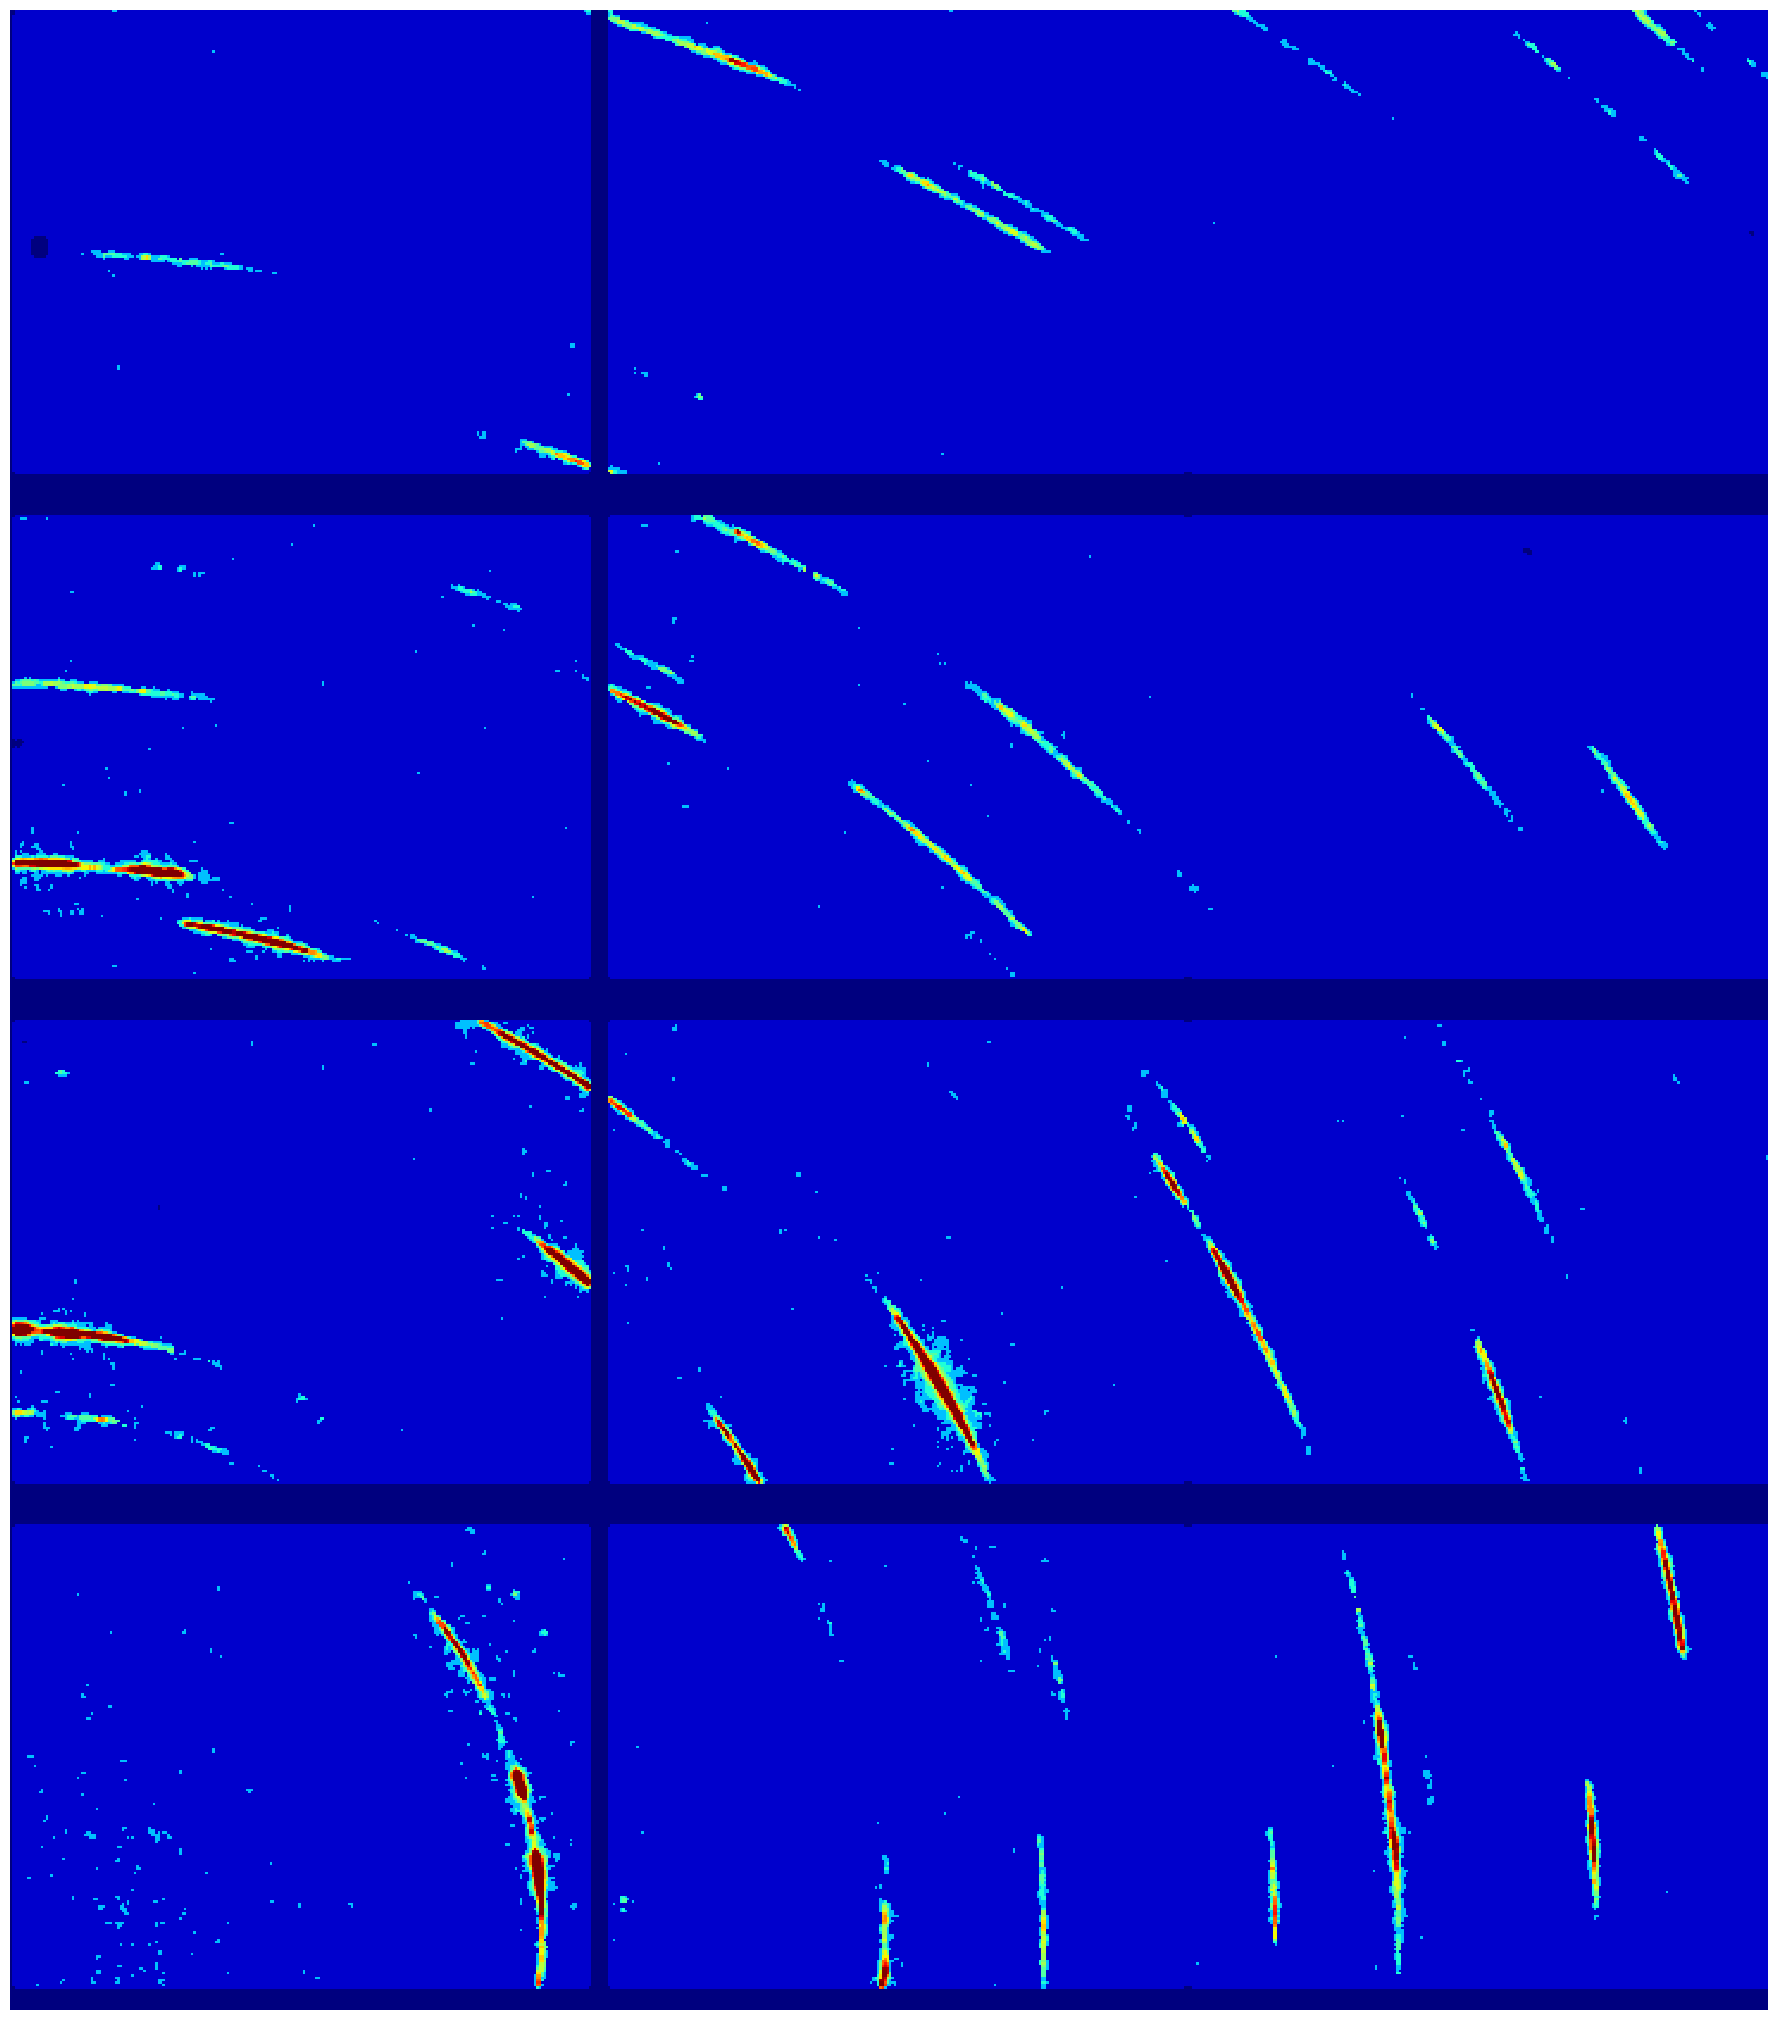

In [10]:
import h5py
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

with h5py.File(datapath + "scan-0054_pilatus.h5", 'r') as f:
    dataset = f['entry/instrument/pilatus/data']
    detector_image = dataset[3003*6:3003*6+2].mean(axis=0)*6
    nx, ny = detector_image.shape
    detector_image = detector_image[nx//2:,ny//2:]

#detector_image = gaussian_filter(detector_image, sigma=2.0)
fig, ax = plt.subplots(figsize=(20, 20))

detector_image[detector_image<0] = -2
detector_image[(detector_image<=3)*(detector_image>=0)] = 0

from scipy.ndimage import median_filter
detector_image = median_filter(detector_image, size=3)

# transparent background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

from matplotlib.colors import LogNorm
eps = 5
ax.imshow(
    detector_image+eps,
    interpolation='nearest',
    cmap='jet',
    norm=LogNorm(vmin=4, vmax=100),
    origin='lower',
)

# remove everything
ax.axis("off")

# remove all margins
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# save
fig.savefig(
    OUT_DIR / Path("detector_sharptexture.png"),
    dpi=200,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)


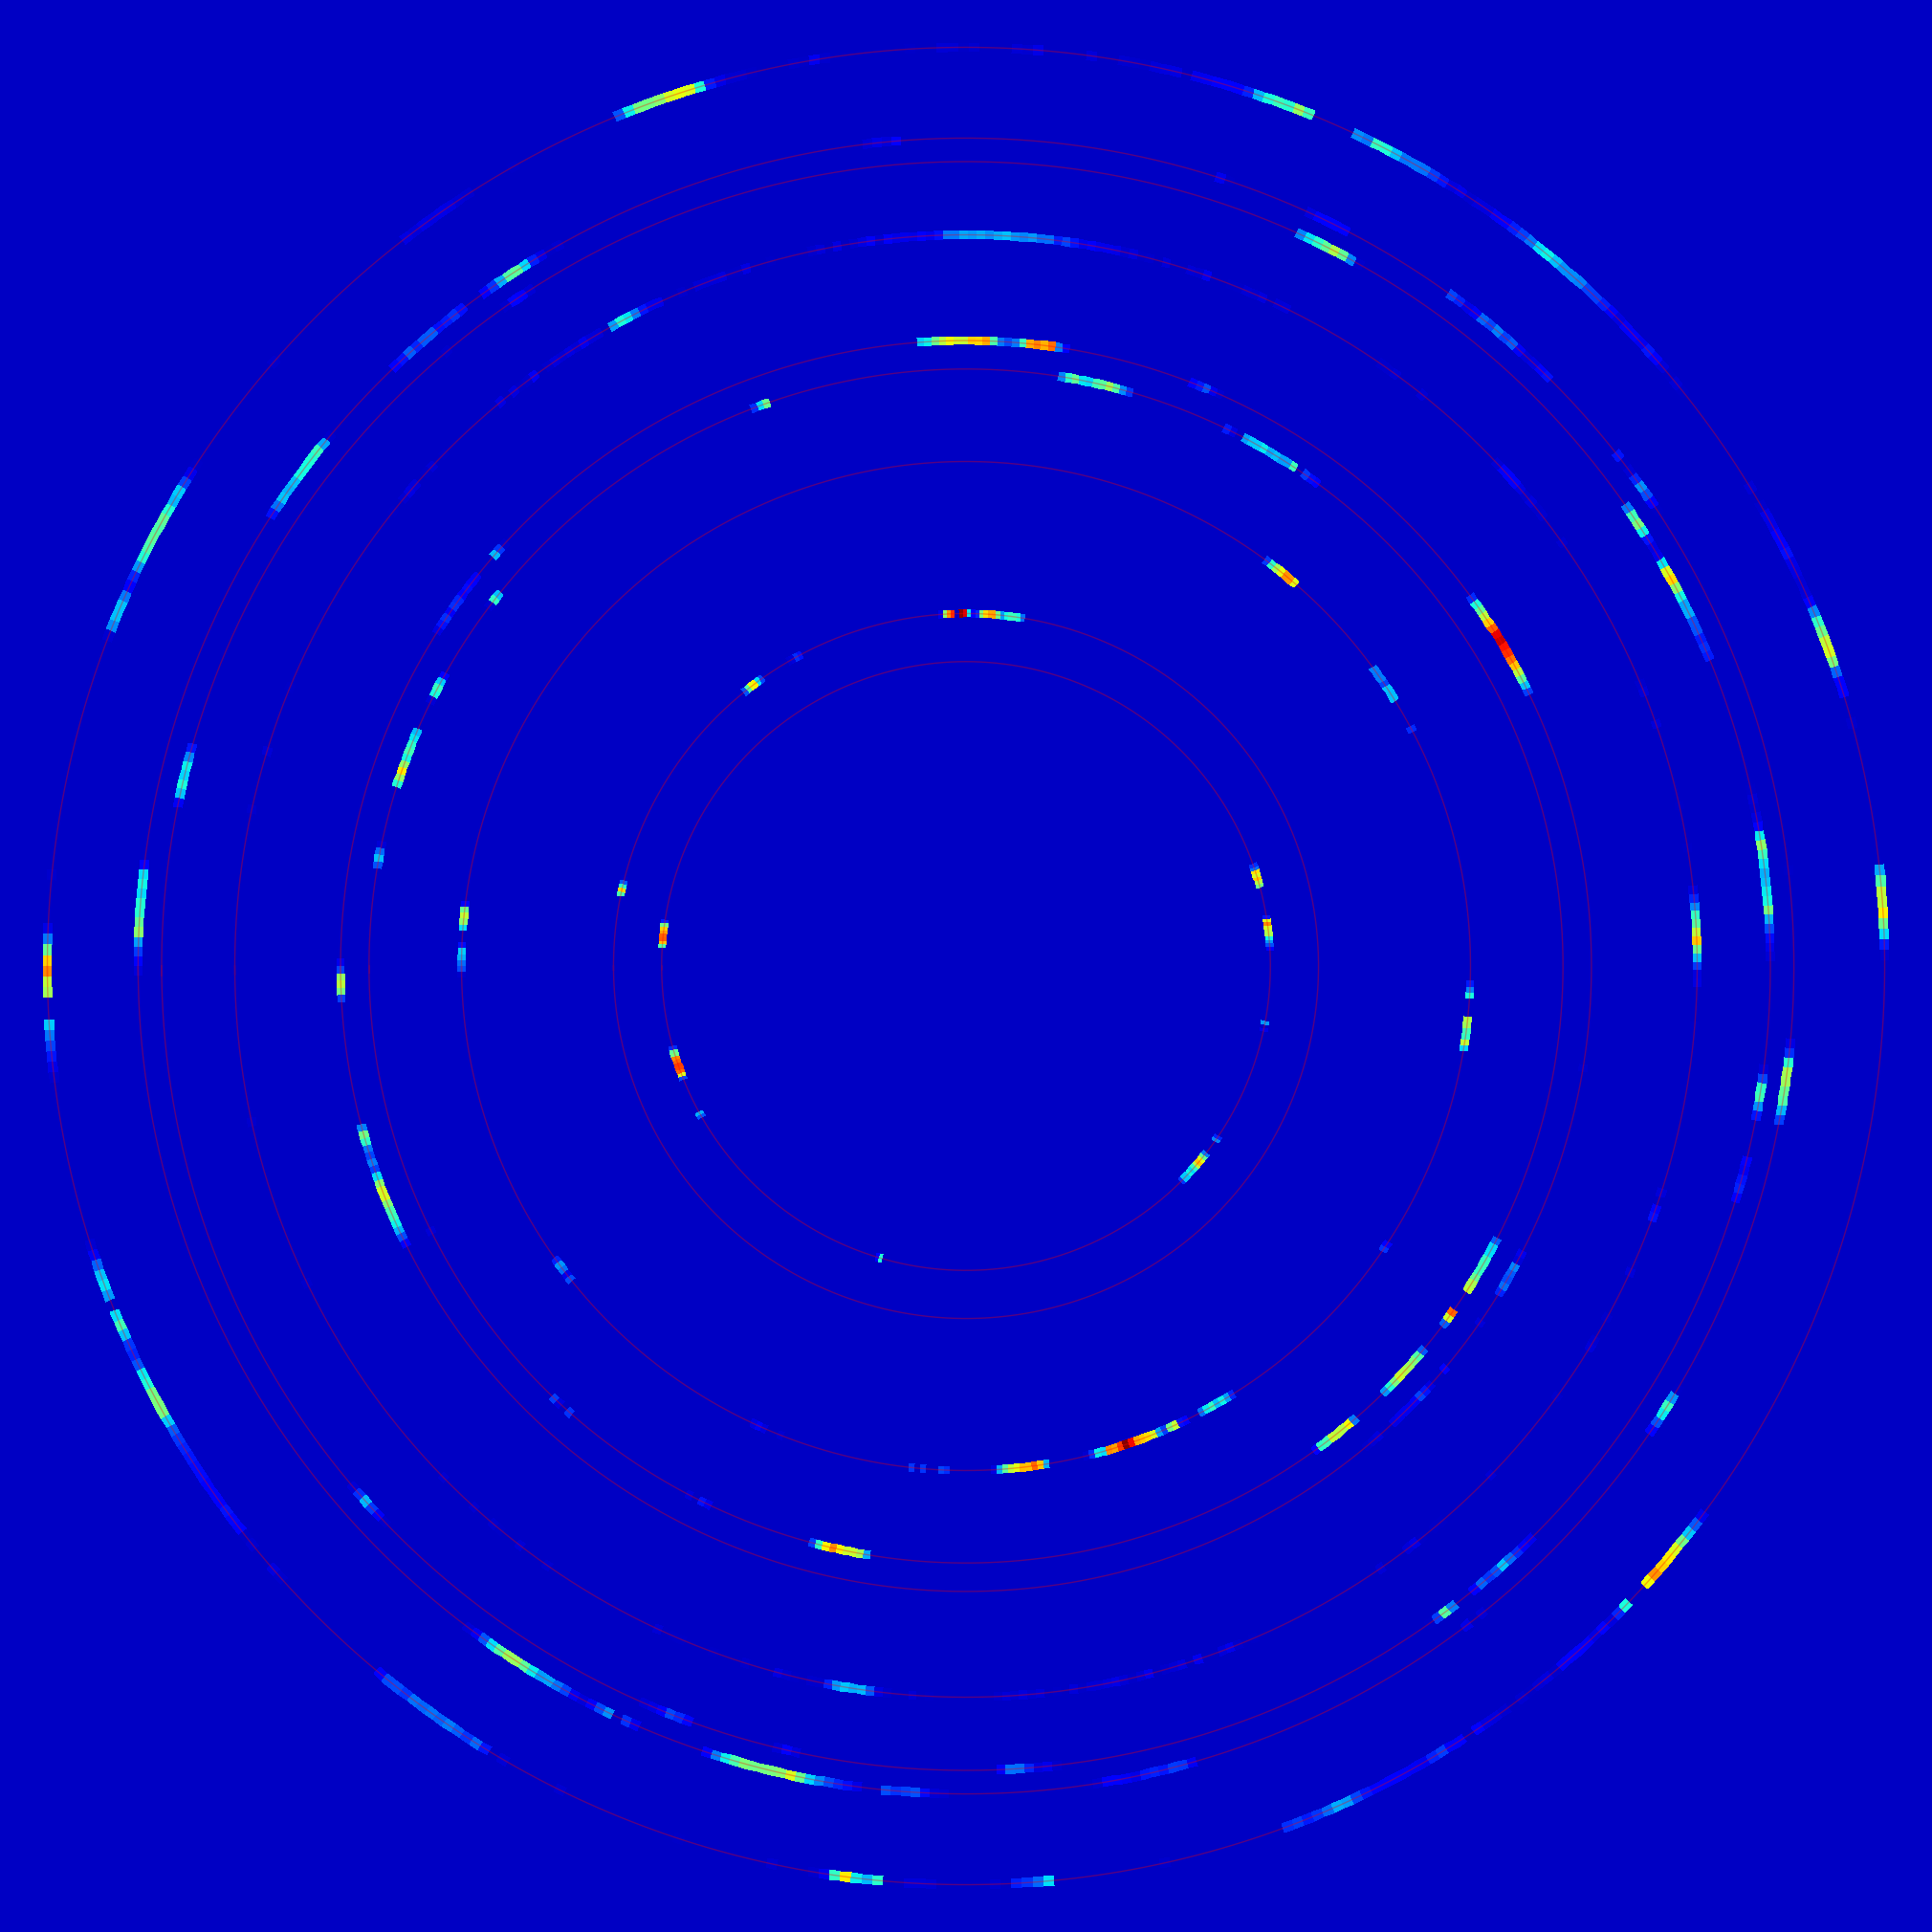

In [39]:
all_data_reshaped = np.load('/work3/msaca/integrated_data_omega=500.npy')
all_data_reshaped = all_data_reshaped.reshape((N_Omega, My, N_eta, N_theta))

n_eta = 540

eta = np.linspace(-180, 180, n_eta) + 360/n_eta/2
centers = np.array([8.0, 10.0, 13.0])
widths = np.array([0.2, 0.2, 0.2])

width_two_theta = 0.0075*180/np.pi/2
peaks_two_theta = np.array([0.15253486, 0.17618918, 0.24949356 , 0.29284422, 0.30596612, 0.3537646, 0.38588877, 0.39604488, 0.43442364])*180/np.pi


eps2 = 2.0
eps = 1.5
fig, ax, _ = plot_ring_arcs_clean(
    values=np.clip(all_data_reshaped[0,90], a_min = eps2, a_max = 1000000),
    eta_centers_deg=eta,
    two_theta_centers_deg=peaks_two_theta,
    two_theta_widths_deg=width_two_theta,
    dist_mm=245.0,
    two_theta_max_deg=0.45*180/np.pi,
    cmap="jet",
    vmin = -100000,
    vmax = 200,
    eps = eps,
    eps2 = eps2
)

plt.savefig(
    OUT_DIR / Path("detector_integrated.png"),
    dpi=200,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0,
)
plt.show()

In [5]:
all_data_reshaped = np.load('/work3/msaca/integrated_data_omega=500.npy')

# ---------------------------
# MATERIAL
# ---------------------------
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
path = cif_folder / filenames[0]

material = Material.from_cif(
    cif_path=path,
    wavelength_kev=wavelength_kev,
    min_two_theta=min_two_theta,
    max_two_theta=max_two_theta,
    intensity_cutoff_fraction=reflection_cutoff,
)


print(f"Loading {RECON_PATH} …")
with h5py.File(RECON_PATH, 'r') as f:
    x_full = f['x'][()].astype(np.float64)      # (H, W, K)
    rot_mats = f['orientations'][()]               # (K, 3, 3)
    sigma_rad = float(f.attrs.get('sigma', 0.007))
    meta = dict(f.attrs)
    x_attrs = dict(f['x'].attrs)

sigma_rad = 0.007
grid = Grid.from_rotation_matrices(rot_mats, sigma=sigma_rad)
print('Generated grid')

# ---------------------------
# OPERATOR
# ---------------------------
op = SinglePhaseForwardOperator(cfg=cfg, material=material, grid=grid, max_gb=1.0,
                verbose=True, normalized=True)

queue = op.queue
Nx, Ny, My, K = op.Nx, op.Ny, op.My, op.K

# ---------------------------
# FORWARD PROJECTION FROM RECONSTRUCTION (OpenCL, Fortran order)
# ---------------------------
x_recon = np.asfortranarray(x_full[::-1, ::-1], dtype=np.float32)
if x_recon.shape == (op.Nx, op.Ny, op.K):
    pass
else:
    raise ValueError(
        f"Unexpected reconstruction shape {x_recon.shape}, expected "
        f"(Nx, Ny, My, K)=({op.Nx}, {op.Ny}, {op.My}, {op.K}) or (Ny, Nx, K)."
    )

x_gpu = clarray.to_device(queue, x_recon)
prediction = clarray.zeros(queue, (N_Omega, My, N_eta*N_theta), dtype=np.float32, order="C")

op.direct_cl(x_gpu,prediction)
prediction_cpu = prediction.get().reshape((N_Omega, My, N_eta, N_theta))
prediction_cpu = prediction_cpu/prediction_cpu.sum()*all_data_reshaped.sum()
print(prediction_cpu.sum())
print(all_data_reshaped.sum())

Loading /work3/msaca/textomo_run_026/reconstruction.h5 …
Generated grid

=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(148x500x110),    31.05 MB
coeffs_sino_C                 : shape=(500x148x110),    31.05 MB
_coeffs_batch_F               : shape=(108x108x110),     4.89 MB
_basis_batch_kmax             : shape=(500x110x540x9),  1019.67 MB
_basis_batch_transpose_kmax   : shape=(500x4860x110),  1019.67 MB
_grid_inv_kmax                : shape=(110x9),     0.00 MB
_inv_sigma2_kmax              : shape=(110),     0.00 MB
_norm_factor_kmax             : shape=(110),     0.00 MB
---------------------------------------
TOTAL GPU buffer memory:  2106.34 MB

6.8006426e+08
6.800643e+08


Converting rotation matrices to Rodrigues vectors ...
Rodrigues vectors shape: (37599, 3)
Done.


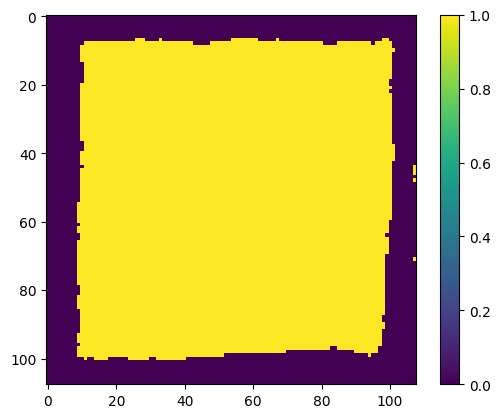

In [6]:
plt.imshow(x_full.sum(axis=-1, keepdims = True)>0.015)
plt.colorbar()
x_fullN = x_full/x_full.sum(axis=-1, keepdims = True)
x_example_pixel = x_fullN[50,50]
x_total = x_fullN[(x_full.sum(axis=-1) > 0.015)].mean(axis=0)

print("Converting rotation matrices to Rodrigues vectors ...")
rot = Rotation.from_matrix(rot_mats)   # infer from (K, 3, 3)

rotvec = rot.as_rotvec()          # shape (K, 3), each row = omega * n_hat
omega = np.linalg.norm(rotvec, axis=1, keepdims=True)   # shape (K, 1)

# Avoid division by zero for near-identity rotations
safe_omega = np.where(omega < 1e-10, 1.0, omega)
n_hat = rotvec / safe_omega                               # unit axis

tan_half = np.where(omega < 1e-10, 0.0, np.tan(omega / 2.0))  # (K, 1)

rodrigues = tan_half * n_hat      # shape (K, 3), r = tan(omega/2) * n_hat
print(f"Rodrigues vectors shape: {rodrigues.shape}")


with h5py.File(OUT_DIR / Path("bulk_coeffs.h5"), 'w') as f:
    # Main datasets
    f.create_dataset('coefficients_pixel',      data=x_example_pixel,   compression=None)
    f.create_dataset('coefficients_bulk',      data=x_total,   compression=None)
    f.create_dataset('rodrigues_vectors', data=rodrigues,       compression=None)
    f.create_dataset('orientations_rot_matrices', data=rot_mats, compression=None)

    # Pixel index
    f.attrs['pixel_row'] = 50
    f.attrs['pixel_col'] = 50
    f.attrs['pixel_index_description'] = (
        'Row and column index into the (Nx, Ny, K) reconstruction array'
    )

    # Rodrigues convention note
    f.attrs['rodrigues_convention'] = (
        'r = tan(omega/2) * n_hat  '
        'where omega is the rotation angle (radians) and n_hat is the unit '
        'rotation axis.  This is the classical Rodrigues parametrisation. '
        'Shape: (K, 3).'
    )

    # Forward all file-level metadata from the reconstruction
    for key, val in meta.items():
        f.attrs[key] = val

    # Forward x-dataset attributes
    for key, val in x_attrs.items():
        f['coefficients_bulk'].attrs[key] = val

    f.attrs['reconstruction_file'] = str(RECON_PATH)
    f.attrs['n_orientations'] = K

print("Done.")

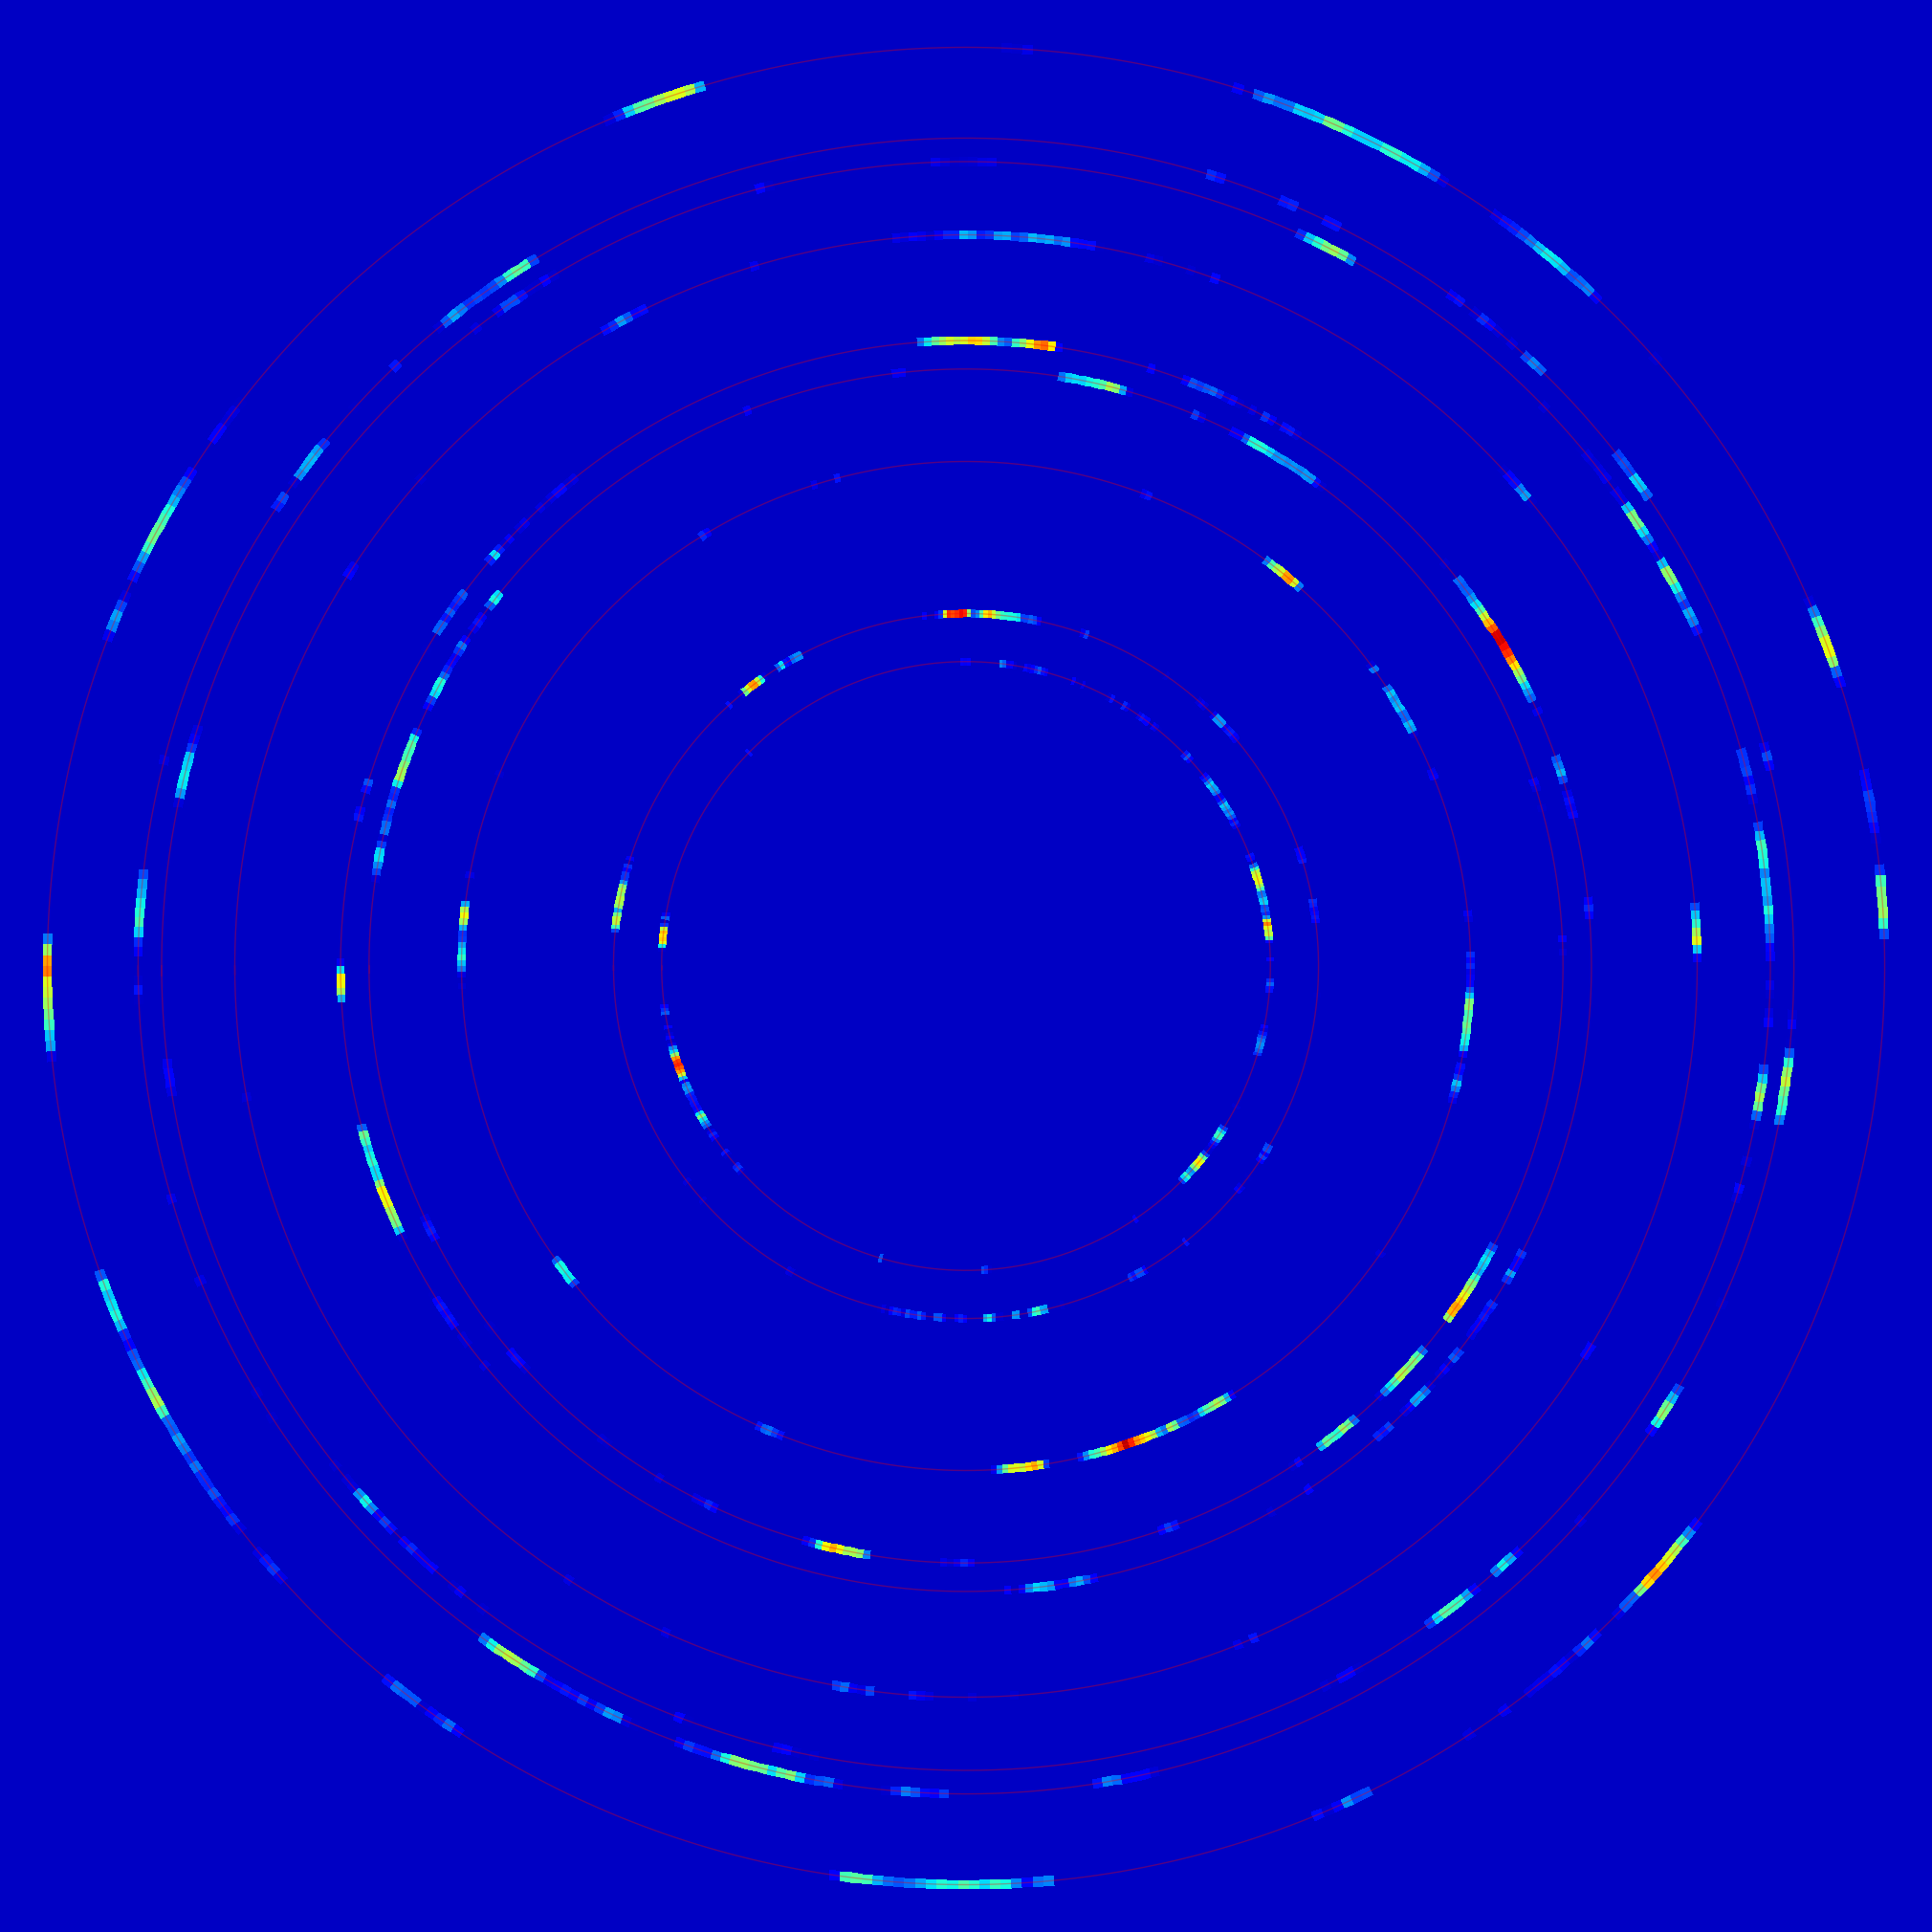

In [7]:
eps2 = 2.0
eps = 1.5
fig, ax, _ = plot_ring_arcs_clean(
    values=np.clip(prediction_cpu[0,90], a_min = eps2, a_max = 1000000),
    eta_centers_deg=eta,
    two_theta_centers_deg=peaks_two_theta,
    two_theta_widths_deg=width_two_theta,
    dist_mm=245.0,
    two_theta_max_deg=0.45*180/np.pi,
    cmap="jet",
    vmin = -100000,
    vmax = 200,
    eps = eps,
    eps2 = eps2
)

plt.savefig(
    OUT_DIR / Path("detector_integrated_prediction.png"),
    dpi=200,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0,
)
plt.show()

In [ ]:
def plot_ring_arcs_clean2(
    values,
    eta_centers_deg,
    two_theta_centers_deg,
    two_theta_widths_deg,
    dist_mm,
    two_theta_max_deg,
    cmap="RdBu",
    vmax=None,
):
    """
    Plot ring-arc data on a square Cartesian figure with no axes or colorbar.
    Zero is white (background), negative values are red, positive values are blue.
    Color range is [-vmax, vmax].

    Parameters
    ----------
    values : array, shape (N_eta, N_2theta)
        Data values for each eta bin and each ring.
    eta_centers_deg : array, shape (N_eta,)
        Linearly spaced eta bin centers in degrees.
    two_theta_centers_deg : array, shape (N_2theta,)
        Ring center positions in 2theta degrees.
    two_theta_widths_deg : array, shape (N_2theta,)
        Ring thicknesses in 2theta degrees.
    dist_mm : float
        Sample-detector distance in mm.
    two_theta_max_deg : float
        Outer radial limit in 2theta for the plotted region.
    """

    def edges_from_linear_centers(c):
        c = np.asarray(c, dtype=float)
        if len(c) < 2:
            raise ValueError("eta_centers_deg must contain at least 2 points")
        step = c[1] - c[0]
        if not np.allclose(np.diff(c), step):
            raise ValueError("eta_centers_deg must be linearly spaced")
        e = np.empty(len(c) + 1, dtype=float)
        e[1:-1] = 0.5 * (c[:-1] + c[1:])
        e[0] = c[0] - 0.5 * step
        e[-1] = c[-1] + 0.5 * step
        return e

    def detector_radius(two_theta_deg):
        return dist_mm * np.tan(np.deg2rad(two_theta_deg))

    def build_intervals(centers, widths):
        centers = np.asarray(centers, dtype=float)
        widths = np.asarray(widths, dtype=float)

        lowers = centers - 0.5 * widths
        uppers = centers + 0.5 * widths

        order = np.argsort(centers)
        lowers = lowers[order]
        uppers = uppers[order]

        if np.any(lowers[1:] < uppers[:-1]):
            raise ValueError("Ring intervals overlap")

        intervals = []
        current = 0.0

        for i, (lo, hi) in enumerate(zip(lowers, uppers)):
            if lo > current:
                intervals.append((current, lo, None))
            intervals.append((lo, hi, order[i]))
            current = hi

        if current < two_theta_max_deg:
            intervals.append((current, two_theta_max_deg, None))

        return intervals

    values = np.asarray(values)
    eta_centers_deg = np.asarray(eta_centers_deg, dtype=float)
    two_theta_centers_deg = np.asarray(two_theta_centers_deg, dtype=float)
    two_theta_widths_deg = np.asarray(two_theta_widths_deg, dtype=float)

    n_eta = len(eta_centers_deg)
    n_rings = len(two_theta_centers_deg)

    if values.shape != (n_eta, n_rings):
        raise ValueError(
            f"values must have shape ({n_eta}, {n_rings}), got {values.shape}"
        )

    eta_edges = edges_from_linear_centers(eta_centers_deg)
    intervals = build_intervals(two_theta_centers_deg, two_theta_widths_deg)

    z_rows = []
    radial_edges = [intervals[0][0]]

    for lo, hi, idx in intervals:
        radial_edges.append(hi)
        if idx is None:
            z_rows.append(np.zeros(n_eta, dtype=values.dtype))
        else:
            z_rows.append(values[:, idx])

    Z = np.asarray(z_rows)  # shape: (N_intervals, N_eta)
    radial_edges = np.asarray(radial_edges, dtype=float)

    r_edges = detector_radius(radial_edges)

    Eta, R = np.meshgrid(np.deg2rad(eta_edges), r_edges, indexing="xy")
    X = R * np.cos(Eta)
    Y = R * np.sin(Eta)

    fig, ax = plt.subplots(figsize=(20, 20))

    if vmax is None:
        vmax = float(np.max(np.abs(Z)))

    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    pcm = ax.pcolormesh(
        X,
        Y,
        Z,
        shading="flat",
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
    )

    phi_deg = np.linspace(eta_edges[0], eta_edges[-1], 1000)
    phi = np.deg2rad(phi_deg)

    for c in two_theta_centers_deg:
        r = detector_radius(c)
        ax.plot(r * np.cos(phi), r * np.sin(phi), color="black", lw=1.0, alpha=0.35)

    rmax = r_edges.max()
    ax.set_xlim(-rmax, rmax)
    ax.set_ylim(-rmax, rmax)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

    return fig, ax, pcm


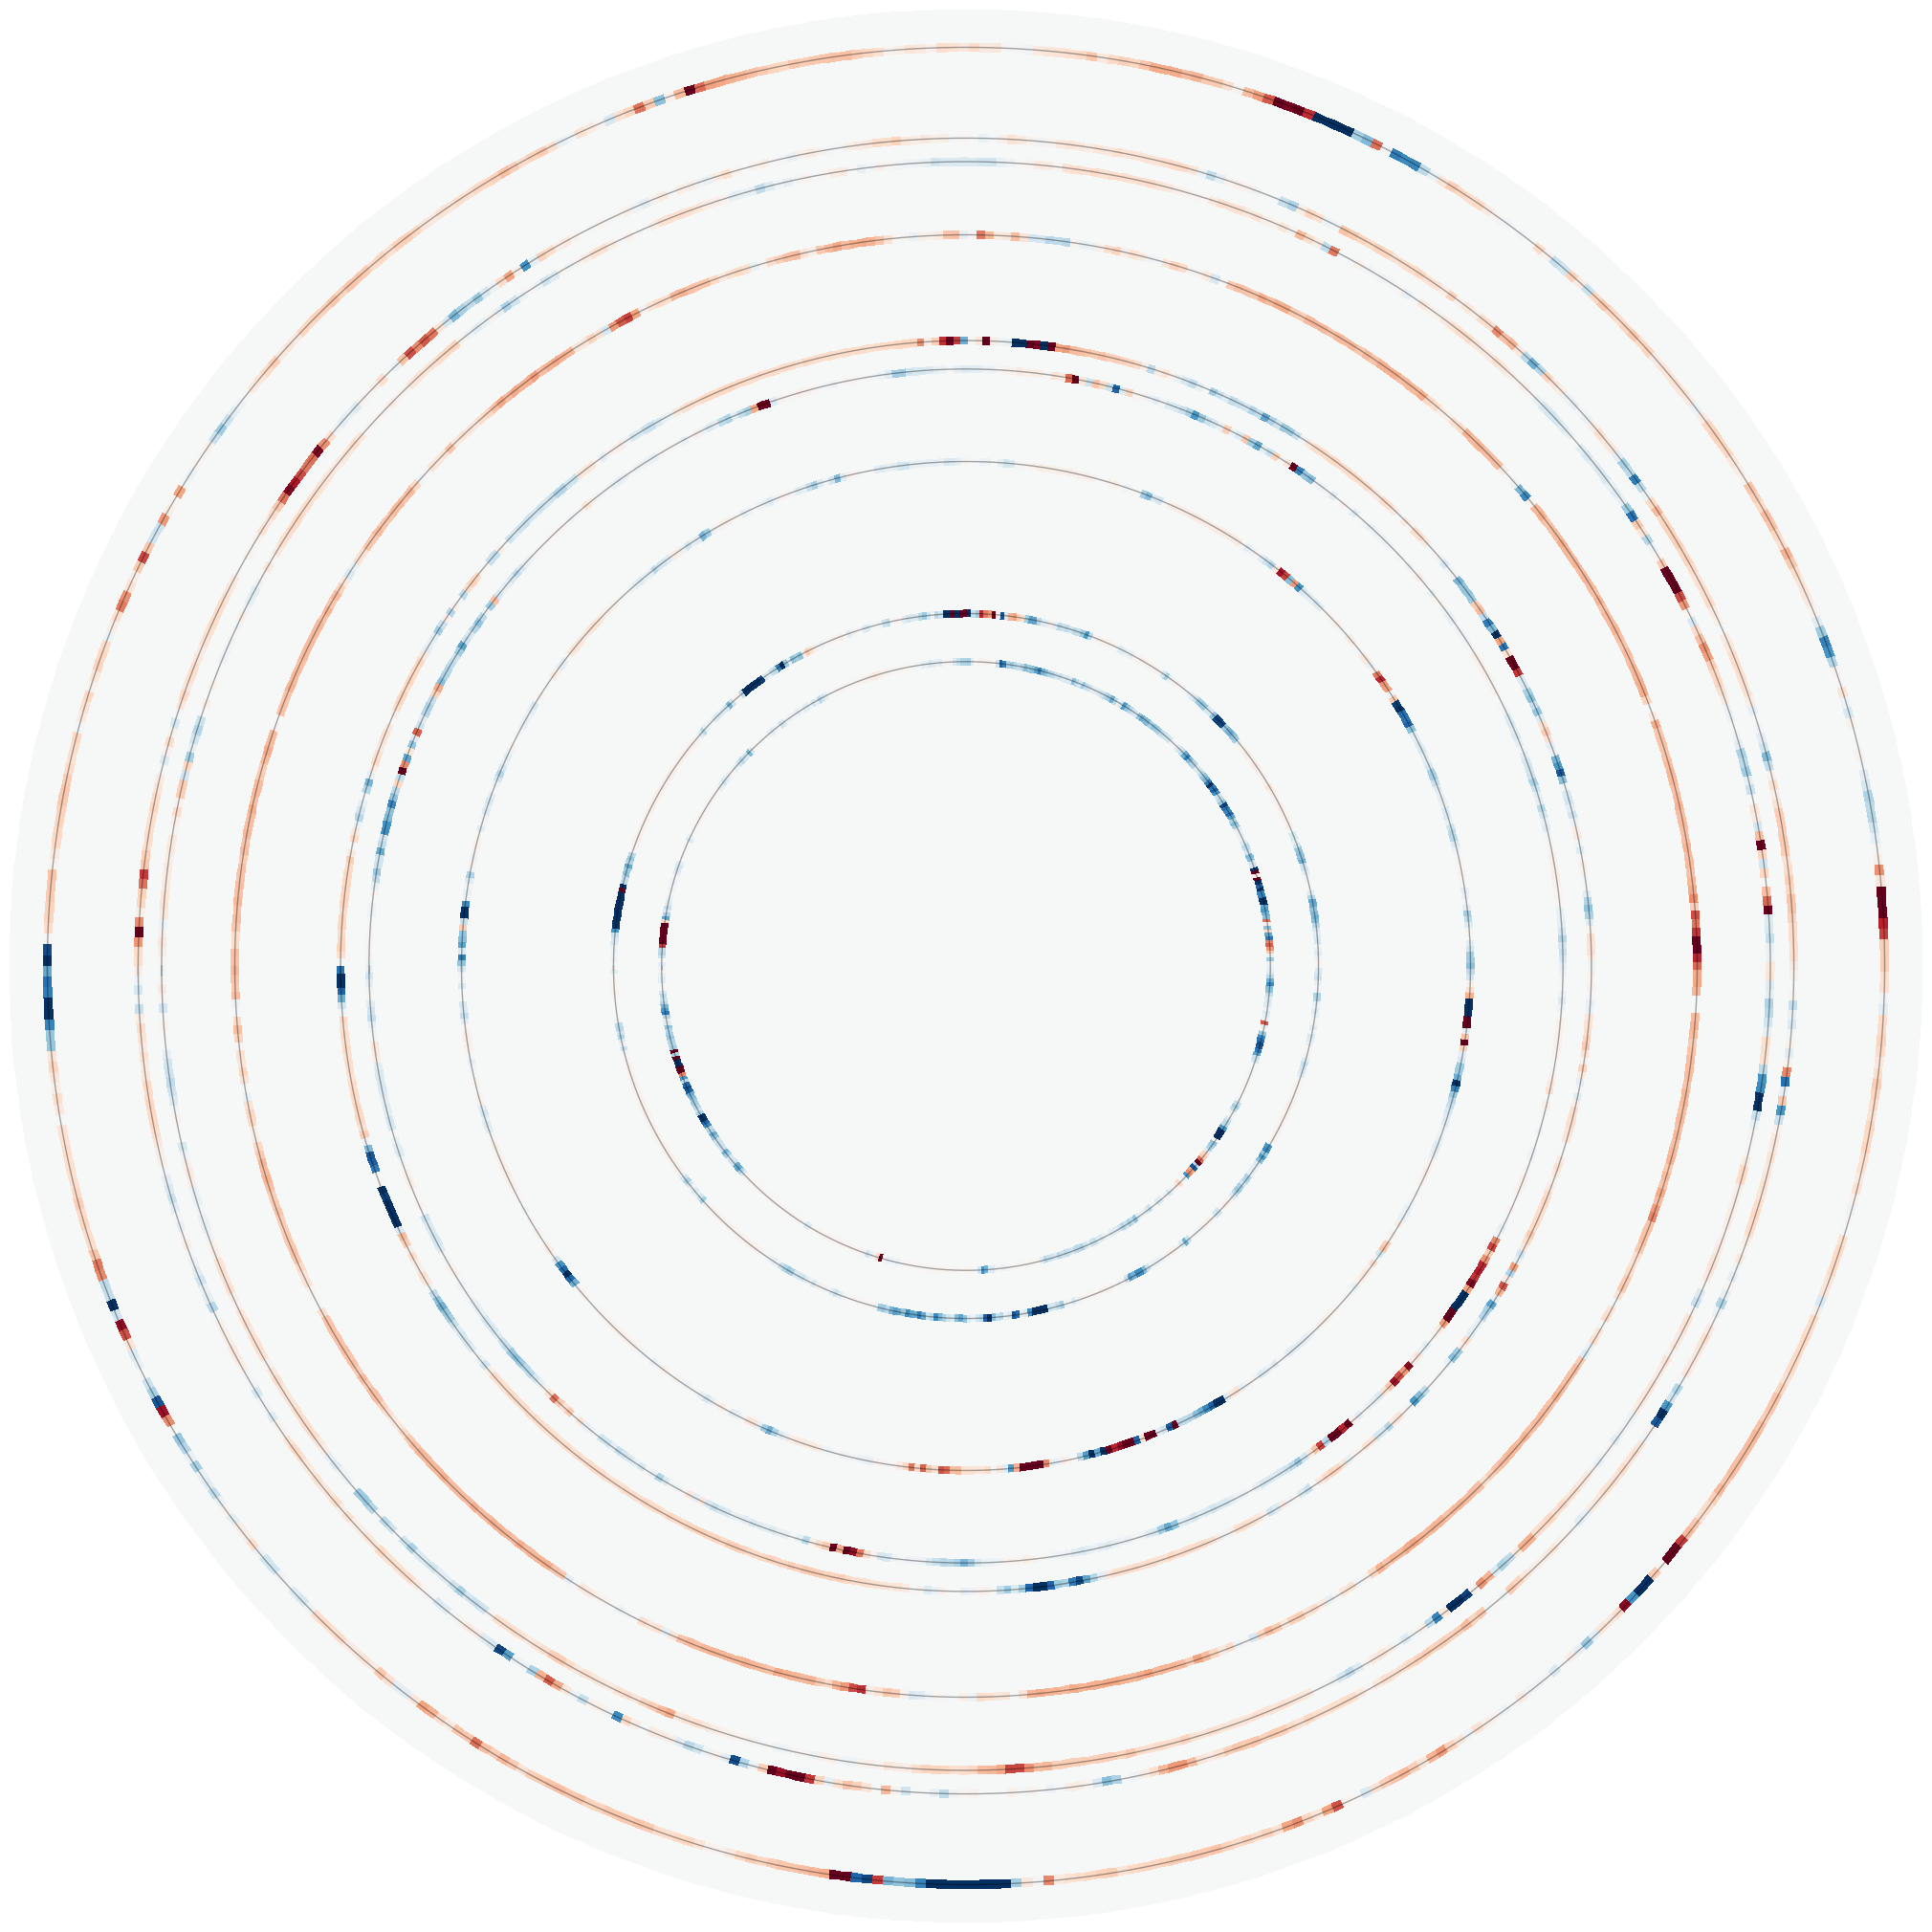

In [9]:
fig, ax, _ = plot_ring_arcs_clean2(
    values = prediction_cpu[0,90] - all_data_reshaped.reshape((N_Omega, My, N_eta, N_theta))[0,90],
    eta_centers_deg = eta,
    two_theta_centers_deg=peaks_two_theta,
    two_theta_widths_deg=width_two_theta,
    dist_mm=245.0,
    two_theta_max_deg=0.45*180/np.pi,
    cmap="RdBu",
    vmax=6,
)


plt.savefig(
    OUT_DIR / Path("detector_integrated_residuals.png"),
    dpi=200,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0,
)
plt.show()

In [10]:
all_data_reshaped = np.load('/work3/msaca/integrated_data_omega=500.npy')

config_path = "/zhome/71/c/146676/texture_tomography/" + "configs/" + "aluminum_config_uniform.yaml"

with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)



# ---------------------------
# MATERIAL
# ---------------------------
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
path = cif_folder / filenames[0]

material = Material.from_cif(
    cif_path=path,
    wavelength_kev=wavelength_kev,
    min_two_theta=min_two_theta,
    max_two_theta=max_two_theta,
    intensity_cutoff_fraction=reflection_cutoff,
)

RECON_PATH  = Path('/work3/msaca/textomo_run_031/reconstruction.h5')
sigma_deg = 1.3
sigme_rad = sigma_deg/180*np.pi

print(f"Loading {RECON_PATH} …")
with h5py.File(RECON_PATH, 'r') as f:
    x_full = f['x'][()].astype(np.float64)      # (H, W, K)
    rot_mats = f['orientations'][()]               # (K, 3, 3)
    sigma_rad = float(f.attrs.get('sigma', sigma_rad))
    meta = dict(f.attrs)
    x_attrs = dict(f['x'].attrs)

grid = Grid.from_rotation_matrices(rot_mats, sigma=sigma_rad)
print('Generated grid')

# ---------------------------
# OPERATOR
# ---------------------------
op = SinglePhaseForwardOperator(cfg=cfg, material=material, grid=grid, max_gb=1.0,
                verbose=True, normalized=True)

queue = op.queue
Nx, Ny, My, K = op.Nx, op.Ny, op.My, op.K
N_Omega, N_eta, N_theta = op.N_Omega, op.N_eta, op.N_peaks

# ---------------------------
# FORWARD PROJECTION FROM RECONSTRUCTION (OpenCL, Fortran order)
# ---------------------------
x_recon = np.asfortranarray(x_full[::-1, ::-1], dtype=np.float32)
if x_recon.shape == (op.Nx, op.Ny, op.K):
    pass
else:
    raise ValueError(
        f"Unexpected reconstruction shape {x_recon.shape}, expected "
        f"(Nx, Ny, My, K)=({op.Nx}, {op.Ny}, {op.My}, {op.K}) or (Ny, Nx, K)."
    )

x_gpu = clarray.to_device(queue, x_recon)
prediction = clarray.zeros(queue, (N_Omega, My, N_eta*N_theta), dtype=np.float32, order="C")

op.direct_cl(x_gpu,prediction)
prediction_cpu = prediction.get().reshape((N_Omega, My, N_eta, N_theta))
prediction_cpu = prediction_cpu/prediction_cpu.sum()*all_data_reshaped.sum()
print(prediction_cpu.sum())
print(all_data_reshaped.sum())

Loading /work3/msaca/textomo_run_031/reconstruction.h5 …
Generated grid

=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(148x250x441),    62.24 MB
coeffs_sino_C                 : shape=(250x148x441),    62.24 MB
_coeffs_batch_F               : shape=(108x108x441),    19.62 MB
_basis_batch_kmax             : shape=(250x441x270x9),  1021.99 MB
_basis_batch_transpose_kmax   : shape=(250x2430x441),  1021.99 MB
_grid_inv_kmax                : shape=(441x9),     0.02 MB
_inv_sigma2_kmax              : shape=(441),     0.00 MB
_norm_factor_kmax             : shape=(441),     0.00 MB
---------------------------------------
TOTAL GPU buffer memory:  2188.10 MB

6.800643e+08
6.800643e+08


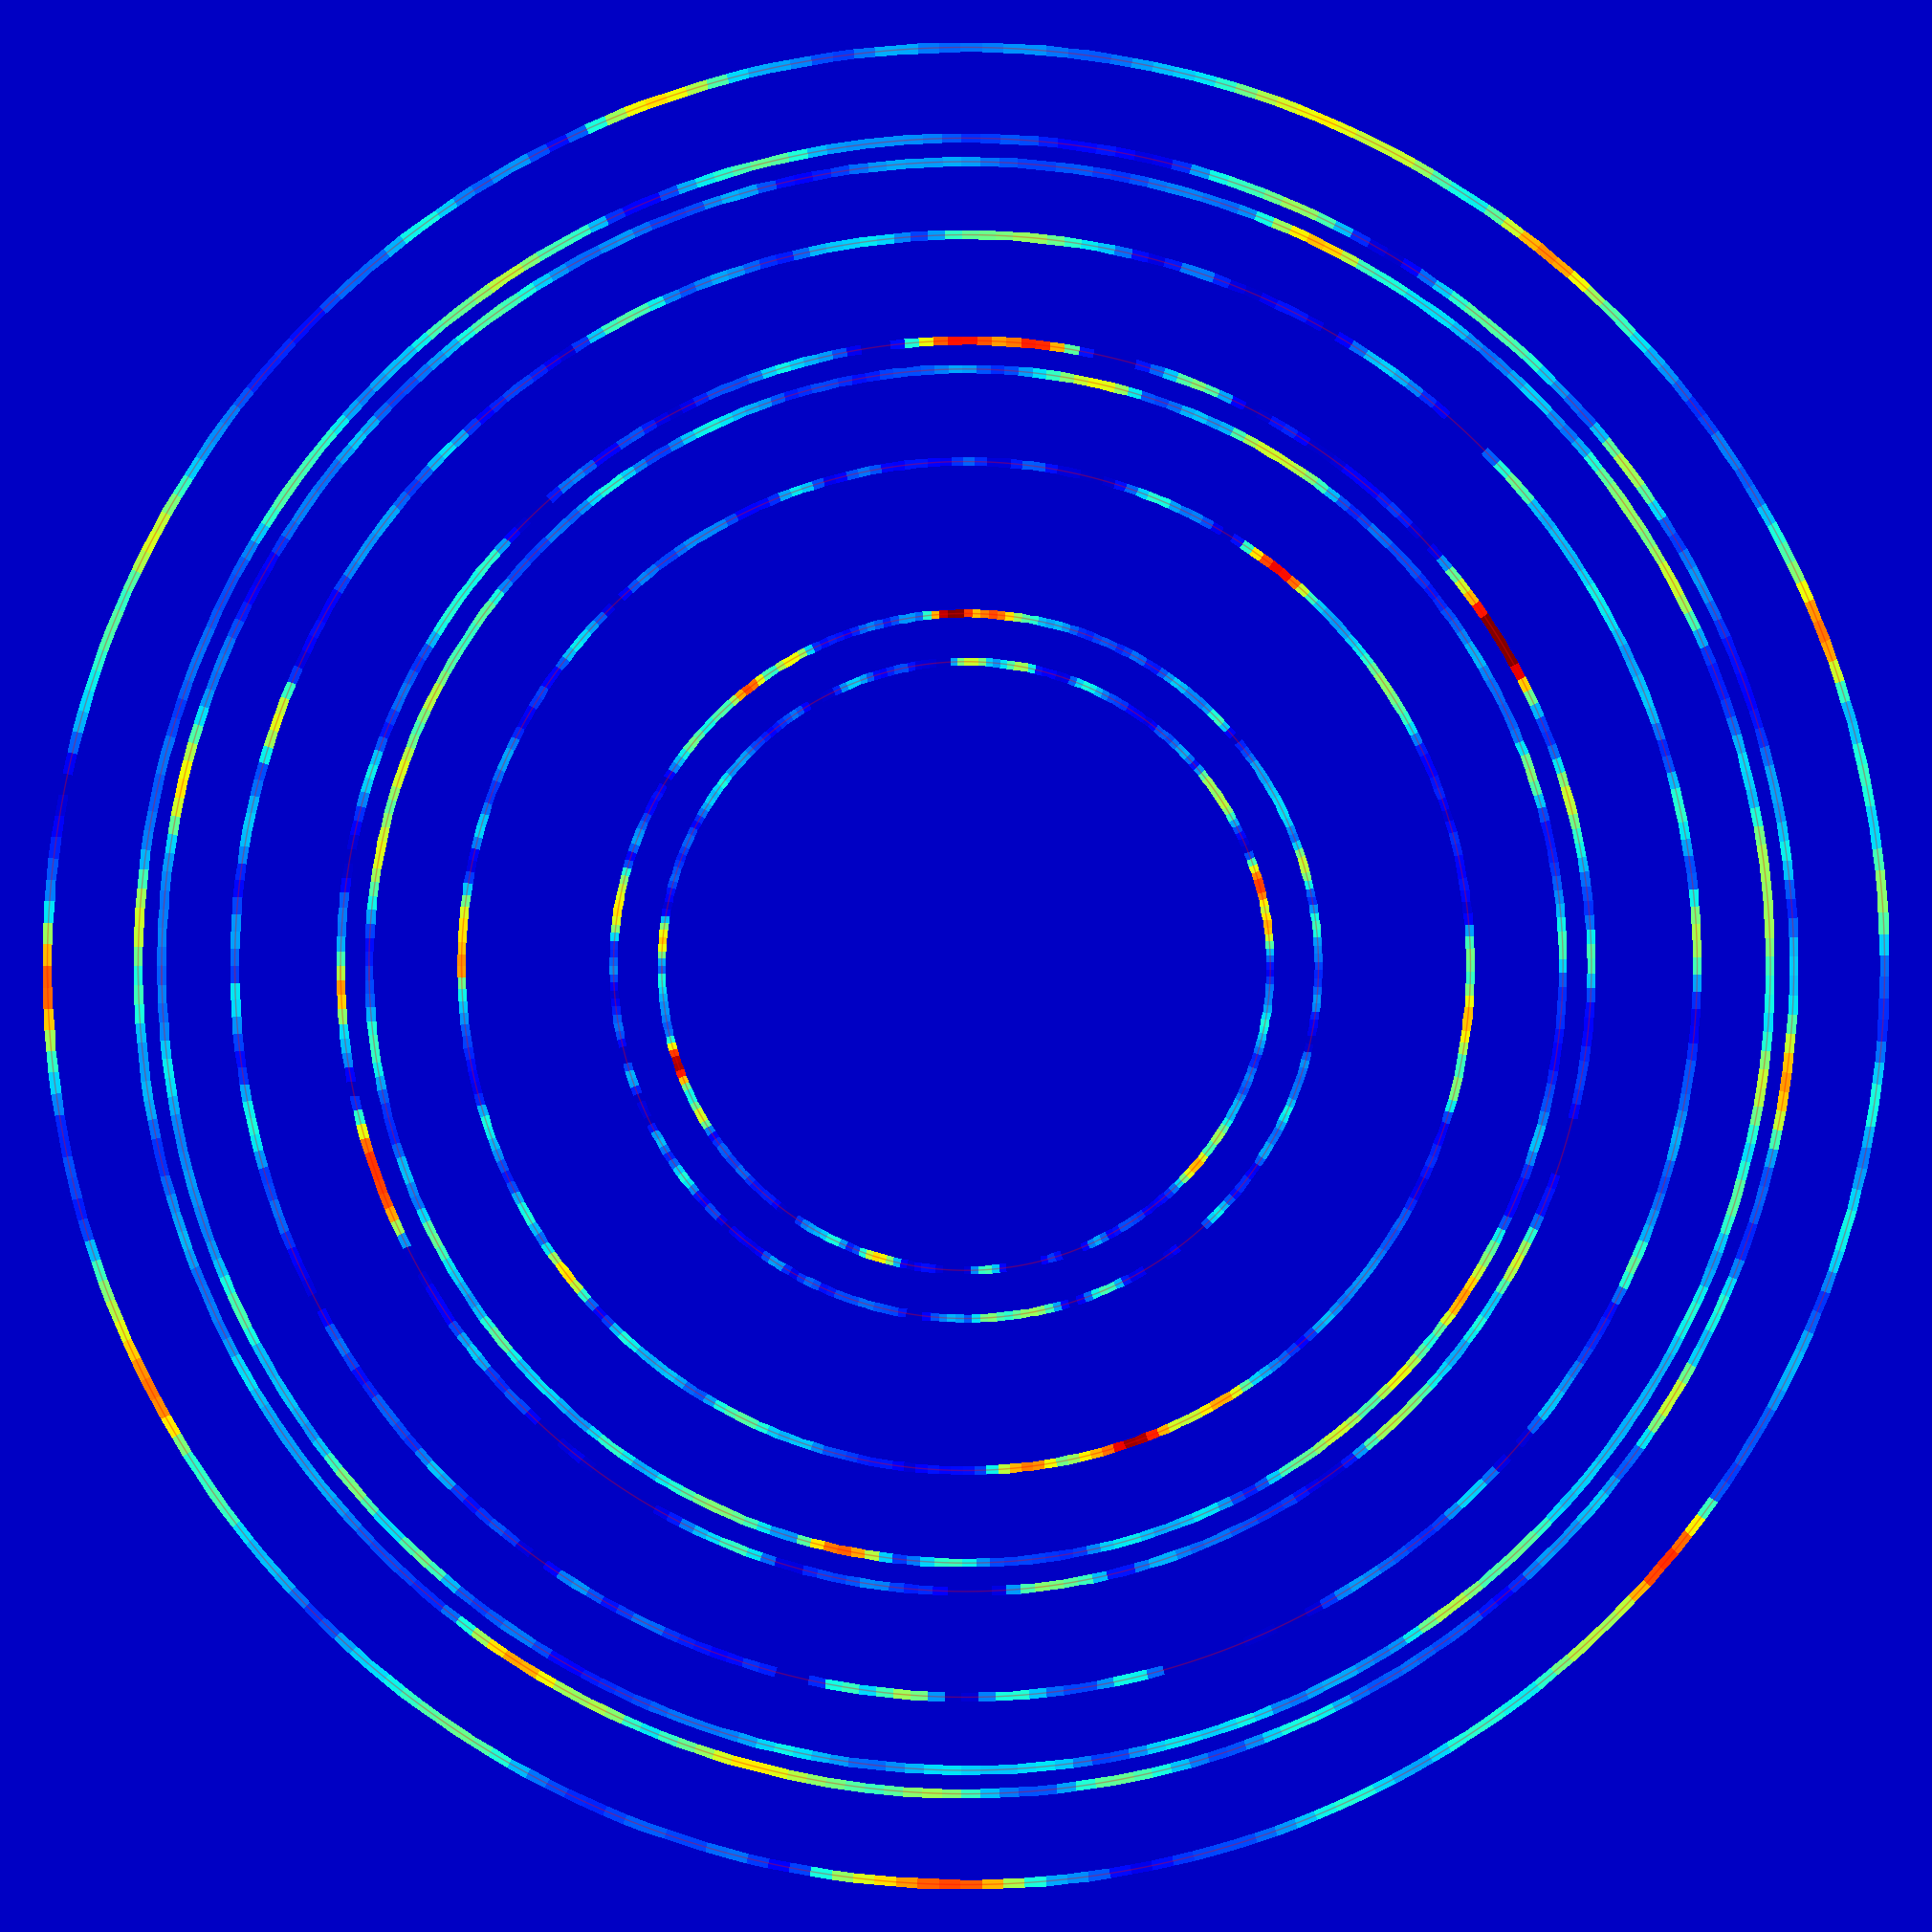

In [11]:
eta = np.linspace(-180, 180, N_eta) + 360/N_eta/2

eps2 = 2.0
eps = 1.5
fig, ax, _ = plot_ring_arcs_clean(
    values=np.clip(prediction_cpu[0,90], a_min = eps2, a_max = 1000000),
    eta_centers_deg=eta,
    two_theta_centers_deg=peaks_two_theta,
    two_theta_widths_deg=width_two_theta,
    dist_mm=245.0,
    two_theta_max_deg=0.45*180/np.pi,
    cmap="jet",
    vmin = -100000,
    vmax = 200,
    eps = eps,
    eps2 = eps2
)

plt.savefig(
    OUT_DIR / Path("detector_integrated_prediction_uniform.png"),
    dpi=200,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0,
)
plt.show()